# Part 04: Ice Phenology Correlation Analysis

**Goal:** Analyze relationships between ice phenology metrics and lake characteristics

**Key Questions:**
1. How does latitude affect ice-on and ice-off timing?
2. Does lake size (area) influence ice-free duration?
3. Do lake shape metrics (circularity, SDI, convexity) correlate with phenology?
4. What is the inter-annual variability (2019-2023)?
5. Are there spatial patterns or regional clusters?

**Input Data:**
- `alaska_lakes_ice_phenology_2019-2023.csv` - Phenology summary with morphometry

**Outputs:**
- Correlation matrices and scatter plots
- Maps showing spatial patterns
- Inter-annual comparison plots
- Statistical summaries by latitude bands

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

FIGURES_DIR = './figures'
os.makedirs(f'{FIGURES_DIR}/manuscript', exist_ok=True)
os.makedirs(f'{FIGURES_DIR}/supplementary', exist_ok=True)
os.makedirs(f'{FIGURES_DIR}/working', exist_ok=True)
os.makedirs('./figure_data', exist_ok=True)

RESULTS_GCS = 'gs://wustl-eeps-geospatial/thermokarst_lakes/results'

print("Libraries loaded")

Libraries loaded


## Part 1: Load Phenology Data

In [2]:
# Load phenology results from GCS (exported from notebook 03)
print("Loading phenology data from GCS...")

BUCKET_NAME = 'wustl-eeps-geospatial'
RESULTS_PATH = 'thermokarst_lakes/results'

# Load phenology data
phenology_url = f'gs://{BUCKET_NAME}/{RESULTS_PATH}/alaska_lakes_ice_phenology_2019-2023.csv'
df = pd.read_csv(phenology_url)

print(f"Loaded {len(df):,} lake-year records")
print(f"Unique lakes: {df['lake_id'].nunique():,}")
print(f"Years: {sorted(df['year'].unique())}")
print(f"\nColumns: {list(df.columns)}")

# Show sample
print("\nSample data:")
display(df.head(3))

Loading phenology data from GCS...


Loaded 155,540 lake-year records
Unique lakes: 31,108
Years: [2019, 2020, 2021, 2022, 2023]

Columns: ['lake_id', 'year', 'centroid_lon', 'centroid_lat', 'area_km2', 'circularity', 'sdi', 'convexity', 'chunk', 'ice_off_date', 'ice_off_doy', 'ice_off_status', 'ice_off_width_days', 'ice_on_date', 'ice_on_doy', 'ice_on_status', 'ice_on_width_days', 'ice_free_days', 'n_spells', 'assign_mode']

Sample data:


,lake_id,year,centroid_lon,centroid_lat,area_km2,circularity,sdi,convexity,chunk,ice_off_date,ice_off_doy,ice_off_status,ice_off_width_days,ice_on_date,ice_on_doy,ice_on_status,ice_on_width_days,ice_free_days,n_spells,assign_mode
0,278001,2019,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2019-06-18 13:02:36.700449653,169.0,exact,12.0,2019-10-14 00:56:14.682392010,287.0,exact,6.0,117.0,1,within_year
1,278001,2020,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2020-06-02 17:16:26.237008717,154.0,exact,2.0,2020-10-07 16:11:51.024191934,281.0,exact,6.0,127.0,1,within_year
2,278001,2021,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2021-06-01 04:41:57.583883678,152.0,exact,14.0,2021-10-02 00:17:27.918893432,275.0,exact,2.0,123.0,1,within_year


In [3]:
# Basic data overview
print("Data Overview:")
print("="*60)
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# Show key phenology stats
print("\n" + "="*60)
print("Key Phenology Variables:")
print("="*60)
for col in ['ice_off_doy', 'ice_on_doy', 'ice_free_days']:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        print(f"{col}: {n_valid} valid values ({100*n_valid/len(df):.1f}%)")

Data Overview:


,lake_id,year,centroid_lon,centroid_lat,area_km2,circularity,sdi,convexity,chunk,ice_off_date,ice_off_doy,ice_off_status,ice_off_width_days,ice_on_date,ice_on_doy,ice_on_status,ice_on_width_days,ice_free_days,n_spells,assign_mode
0,278001,2019,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2019-06-18 13:02:36.700449653,169.0,exact,12.0,2019-10-14 00:56:14.682392010,287.0,exact,6.0,117.0,1,within_year
1,278001,2020,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2020-06-02 17:16:26.237008717,154.0,exact,2.0,2020-10-07 16:11:51.024191934,281.0,exact,6.0,127.0,1,within_year
2,278001,2021,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2021-06-01 04:41:57.583883678,152.0,exact,14.0,2021-10-02 00:17:27.918893432,275.0,exact,2.0,123.0,1,within_year
3,278001,2022,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2022-06-18 17:14:02.573996009,169.0,exact,22.0,2022-09-26 21:28:28.666796211,269.0,exact,10.0,100.0,1,within_year
4,278001,2023,-157.027101,70.805772,0.028192,0.514525,1.394109,0.910838,0,2023-06-14 01:12:48.473037064,165.0,exact,14.0,2023-10-11 12:39:28.158672985,284.0,exact,24.0,119.0,1,within_year



Data Types:
lake_id                 int64
year                    int64
centroid_lon          float64
centroid_lat          float64
area_km2              float64
circularity           float64
sdi                   float64
convexity             float64
chunk                   int64
ice_off_date           object
ice_off_doy           float64
ice_off_status         object
ice_off_width_days    float64
ice_on_date            object
ice_on_doy            float64
ice_on_status          object
ice_on_width_days     float64
ice_free_days         float64
n_spells                int64
assign_mode            object
dtype: object

Missing Values:
lake_id                  0
year                     0
centroid_lon             0
centroid_lat             0
area_km2                 0
circularity              0
sdi                      0
convexity                0
chunk                    0
ice_off_date          3846
ice_off_doy           3846
ice_off_status           0
ice_off_width_days    3846
ice_o

In [4]:
# Filter to complete records (both ice-off and ice-on detected)
complete = df[
    df['ice_off_doy'].notna() & 
    df['ice_on_doy'].notna()
].copy()

print(f"Complete records (both dates detected): {len(complete):,} / {len(df):,} ({100*len(complete)/len(df):.1f}%)")
print(f"Unique lakes with complete records: {complete['lake_id'].nunique():,}")

# Show phenology summary stats
if len(complete) > 0:
    print(f"\nPhenology Summary (complete records):")
    print(f"  Ice-off DOY: mean={complete['ice_off_doy'].mean():.1f}, median={complete['ice_off_doy'].median():.1f}")
    print(f"  Ice-on DOY:  mean={complete['ice_on_doy'].mean():.1f}, median={complete['ice_on_doy'].median():.1f}")
    if 'ice_free_days' in complete.columns:
        valid_ifd = complete['ice_free_days'].dropna()
        if len(valid_ifd) > 0:
            print(f"  Ice-free days: mean={valid_ifd.mean():.1f}, median={valid_ifd.median():.1f}")

Complete records (both dates detected): 150,942 / 155,540 (97.0%)
Unique lakes with complete records: 30,725

Phenology Summary (complete records):
  Ice-off DOY: mean=159.0, median=160.0
  Ice-on DOY:  mean=272.8, median=272.0
  Ice-free days: mean=113.8, median=112.0


## Part 2: Latitude Effects on Ice Phenology

In [5]:
# Create latitude bands based on actual data range
lat_min = complete['centroid_lat'].min()
lat_max = complete['centroid_lat'].max()
lat_range = lat_max - lat_min
print(f"Latitude range: {lat_min:.2f}°N to {lat_max:.2f}°N (range: {lat_range:.2f}°)")

# Adjust number of bins based on latitude range
if lat_range < 1:
    # Narrow range - use quartiles instead
    complete['lat_band'] = pd.qcut(
        complete['centroid_lat'], 
        q=4, 
        labels=['Q1 (South)', 'Q2', 'Q3', 'Q4 (North)'],
        duplicates='drop'
    )
    print("\nUsing quartile-based latitude bands (narrow latitude range)")
else:
    # Wide range - use 1-degree bins
    lat_bins = np.arange(np.floor(lat_min), np.ceil(lat_max) + 1, 1)
    lat_labels = [f'{lat_bins[i]:.0f}-{lat_bins[i+1]:.0f}°N' for i in range(len(lat_bins)-1)]
    complete['lat_band'] = pd.cut(
        complete['centroid_lat'], 
        bins=lat_bins,
        labels=lat_labels
    )

print("\nLakes per latitude band:")
print(complete['lat_band'].value_counts().sort_index())

Latitude range: 69.00°N to 71.34°N (range: 2.34°)

Lakes per latitude band:
lat_band
69-70°N     42924
70-71°N    105401
71-72°N      2617
Name: count, dtype: int64


Ice-off vs Latitude: r = 0.522
Ice-on vs Latitude: r = -0.364


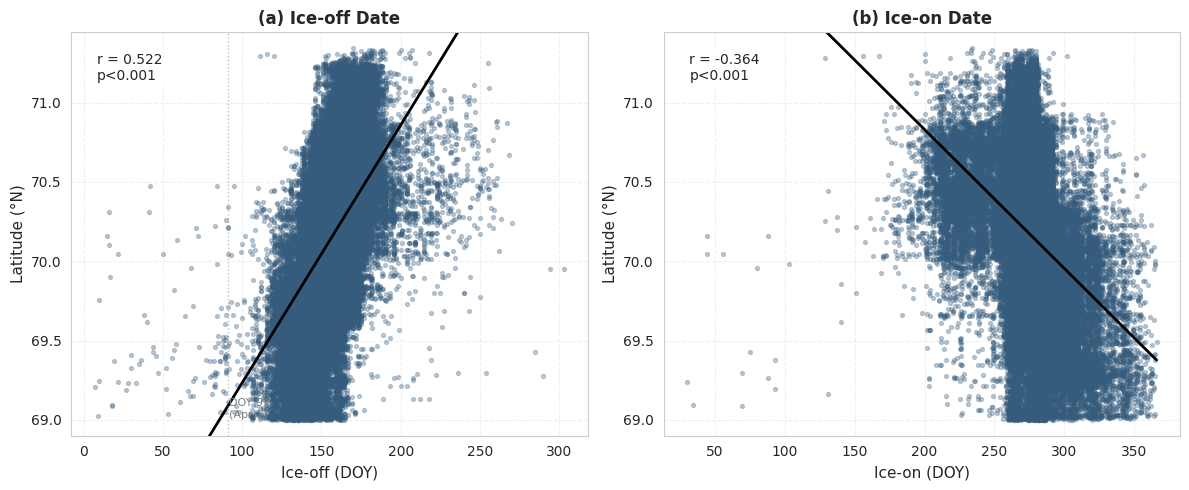

Saved: figures/supplementary/figS_latitude_iceoff_iceon.png
Ice-free vs Latitude: r = -0.501


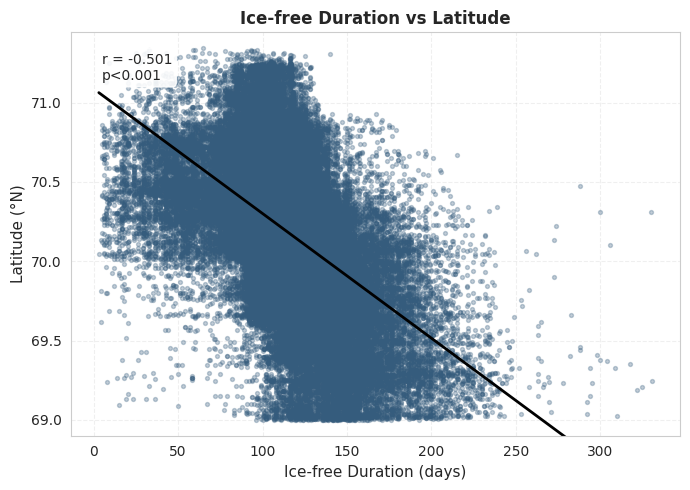


Saved: figures/manuscript/fig04_latitude_icefree.png (300 dpi)
Saved: figure_data/fig04_latitude_icefree.csv


In [6]:
# Set publication-quality styling
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 100,
    'savefig.dpi': 300
})

# Helper function for p-value formatting
def format_pvalue(p):
    """Format p-value for display."""
    if p < 0.001:
        return "p<0.001"
    else:
        return f"p={p:.3f}"

# Muted qualitative palette for years (kept for other figures in notebook)
year_palette = ['#355c7d', '#6c5b7b', '#c06c84', '#f67280', '#f8b500']
years = sorted(complete['year'].unique())
year_colors = {year: year_palette[i] for i, year in enumerate(years)}

# Consistent latitude range
lat_min = complete['centroid_lat'].min()
lat_max = complete['centroid_lat'].max()

# Single color for latitude scatter plots
scatter_color = '#355c7d'

# ============================================================
# Supplementary figure: panels (a) Ice-off and (b) Ice-on
# ============================================================
fig_supp, axes_supp = plt.subplots(1, 2, figsize=(12, 5))

# Panel (a): Ice-off DOY vs Latitude
ax = axes_supp[0]
ax.scatter(complete['ice_off_doy'], complete['centroid_lat'],
           alpha=0.3, s=8, c=scatter_color)

mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
slope, intercept, r, p, se = stats.linregress(
    complete.loc[mask, 'ice_off_doy'],
    complete.loc[mask, 'centroid_lat']
)
x_line = np.linspace(complete['ice_off_doy'].min(), complete['ice_off_doy'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=2)

ax.text(0.05, 0.95, f'r = {r:.3f}\n{format_pvalue(p)}', transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.set_xlabel('Ice-off (DOY)', fontsize=11)
ax.set_ylabel('Latitude (\u00b0N)', fontsize=11)
ax.set_title('(a) Ice-off Date', fontsize=12, fontweight='bold')
ax.set_ylim(lat_min - 0.1, lat_max + 0.1)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axvline(91, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.text(92, lat_min, 'DOY 91\n(Apr 1)', fontsize=8, color='gray', va='bottom')

print(f"Ice-off vs Latitude: r = {r:.3f}")

# Panel (b): Ice-on DOY vs Latitude
ax = axes_supp[1]
ax.scatter(complete['ice_on_doy'], complete['centroid_lat'],
           alpha=0.3, s=8, c=scatter_color)

mask = complete['centroid_lat'].notna() & complete['ice_on_doy'].notna()
slope, intercept, r, p, se = stats.linregress(
    complete.loc[mask, 'ice_on_doy'],
    complete.loc[mask, 'centroid_lat']
)
x_line = np.linspace(complete['ice_on_doy'].min(), complete['ice_on_doy'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=2)

ax.text(0.05, 0.95, f'r = {r:.3f}\n{format_pvalue(p)}', transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.set_xlabel('Ice-on (DOY)', fontsize=11)
ax.set_ylabel('Latitude (\u00b0N)', fontsize=11)
ax.set_title('(b) Ice-on Date', fontsize=12, fontweight='bold')
ax.set_ylim(lat_min - 0.1, lat_max + 0.1)
ax.grid(True, alpha=0.3, linestyle='--')

print(f"Ice-on vs Latitude: r = {r:.3f}")

fig_supp.tight_layout()
os.makedirs('figures/supplementary', exist_ok=True)
fig_supp.savefig('./figures/supplementary/figS_latitude_iceoff_iceon.png',
                 dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS_latitude_iceoff_iceon.png")

# ============================================================
# Manuscript Figure 4: Ice-free Duration vs Latitude
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(complete['ice_free_days'], complete['centroid_lat'],
           alpha=0.3, s=8, c=scatter_color)

mask = complete['centroid_lat'].notna() & complete['ice_free_days'].notna()
slope, intercept, r, p, se = stats.linregress(
    complete.loc[mask, 'ice_free_days'],
    complete.loc[mask, 'centroid_lat']
)
x_line = np.linspace(complete['ice_free_days'].min(), complete['ice_free_days'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=2)

ax.text(0.05, 0.95, f'r = {r:.3f}\n{format_pvalue(p)}', transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.set_xlabel('Ice-free Duration (days)', fontsize=11)
ax.set_ylabel('Latitude (\u00b0N)', fontsize=11)
ax.set_title('Ice-free Duration vs Latitude', fontsize=12, fontweight='bold')
ax.set_ylim(lat_min - 0.1, lat_max + 0.1)
ax.grid(True, alpha=0.3, linestyle='--')

print(f"Ice-free vs Latitude: r = {r:.3f}")

plt.tight_layout()

os.makedirs('figures/manuscript', exist_ok=True)
os.makedirs('figure_data', exist_ok=True)
plt.savefig('./figures/manuscript/fig04_latitude_icefree.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Export figure data
fig4_data = complete[['lake_id', 'year', 'centroid_lat', 'centroid_lon',
                       'ice_off_doy', 'ice_on_doy', 'ice_free_days']].copy()
fig4_data.to_csv('figure_data/fig04_latitude_icefree.csv', index=False)

print("\nSaved: figures/manuscript/fig04_latitude_icefree.png (300 dpi)")
print("Saved: figure_data/fig04_latitude_icefree.csv")

In [7]:
# Summary statistics by latitude band
lat_summary = complete.groupby('lat_band').agg({
    'ice_off_doy': ['mean', 'std', 'count'],
    'ice_on_doy': ['mean', 'std'],
    'ice_free_days': ['mean', 'std']
}).round(1)

print("Phenology by Latitude Band:")
print("="*60)
display(lat_summary)

Phenology by Latitude Band:


ice_off_doy               ice_on_doy       ice_free_days      
                mean   std   count       mean   std          mean   std
lat_band                                                               
69-70°N        150.4  12.8   42924      281.1  17.7         130.8  26.1
70-71°N        162.3  11.1  105401      269.6  15.0         107.3  21.9
71-72°N        170.8  11.7    2617      267.3  13.4          96.5  17.9

## Part 3: Lake Size Effects

In [8]:
# Create size classes
complete['size_class'] = pd.cut(
    complete['area_km2'],
    bins=[0, 0.01, 0.1, 1, 10, 100],
    labels=['<0.01', '0.01-0.1', '0.1-1', '1-10', '>10']
)

print("Lakes per size class:")
print(complete['size_class'].value_counts().sort_index())

Lakes per size class:
size_class
<0.01           0
0.01-0.1    92462
0.1-1       49970
1-10         8280
>10           225
Name: count, dtype: int64


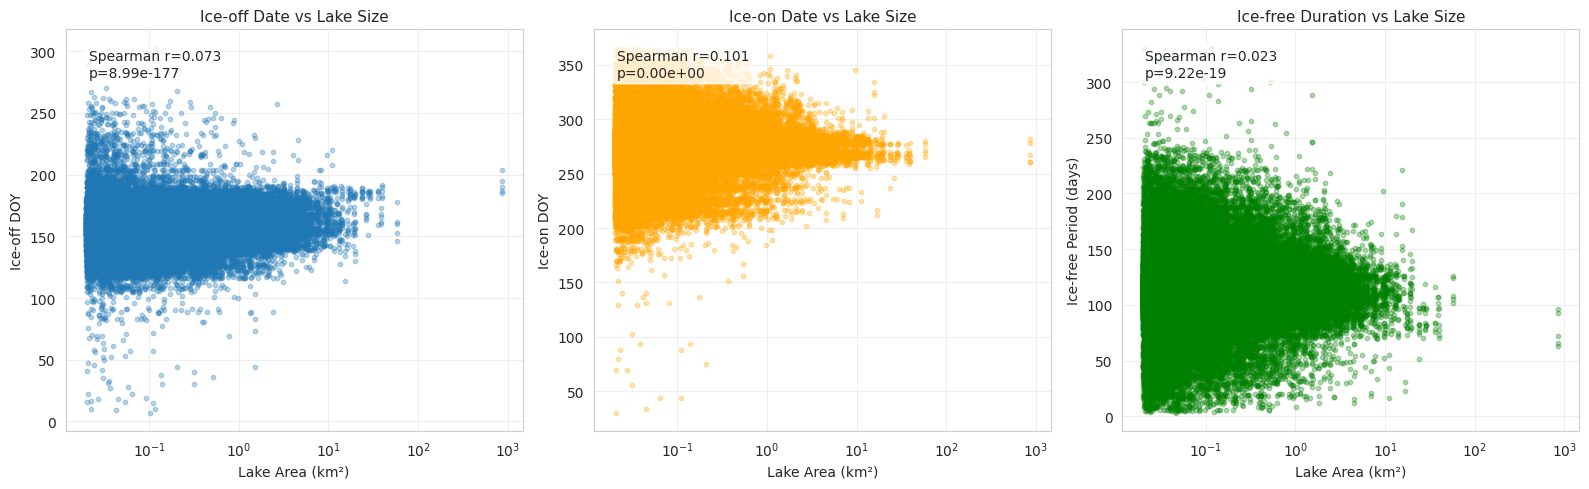

Saved: figures/supplementary/figS06_size_phenology.png


In [9]:
# Lake size vs phenology
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ice-off vs area (log scale)
ax = axes[0]
ax.scatter(complete['area_km2'], complete['ice_off_doy'], alpha=0.3, s=10)
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Lake Size')
# Correlation on log-transformed area
mask = (complete['area_km2'] > 0) & complete['ice_off_doy'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_off_doy'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# Ice-on vs area
ax = axes[1]
ax.scatter(complete['area_km2'], complete['ice_on_doy'], alpha=0.3, s=10, color='orange')
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Lake Size')
mask = (complete['area_km2'] > 0) & complete['ice_on_doy'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_on_doy'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# Ice-free days vs area
ax = axes[2]
ax.scatter(complete['area_km2'], complete['ice_free_days'], alpha=0.3, s=10, color='green')
ax.set_xscale('log')
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Lake Size')
mask = (complete['area_km2'] > 0) & complete['ice_free_days'].notna()
r, p = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_free_days'])
ax.text(0.05, 0.95, f'Spearman r={r:.3f}\np={p:.2e}', transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/supplementary/figS06_size_phenology.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS06_size_phenology.png")

In [10]:
# Summary by size class
size_summary = complete.groupby('size_class').agg({
    'ice_off_doy': ['mean', 'std', 'count'],
    'ice_on_doy': ['mean', 'std'],
    'ice_free_days': ['mean', 'std']
}).round(1)

print("Phenology by Size Class:")
print("="*60)
display(size_summary)

Phenology by Size Class:


ice_off_doy              ice_on_doy       ice_free_days      
                  mean   std  count       mean   std          mean   std
size_class                                                              
<0.01              NaN   NaN      0        NaN   NaN           NaN   NaN
0.01-0.1         158.5  12.7  92462      272.0  17.6         113.5  26.3
0.1-1            159.6  13.0  49970      274.1  15.2         114.5  24.4
1-10             161.1  13.2   8280      274.4  12.6         113.3  22.2
>10              167.2  16.0    225      272.4  13.0         105.2  24.9

## Part 4: Shape Metrics Correlations

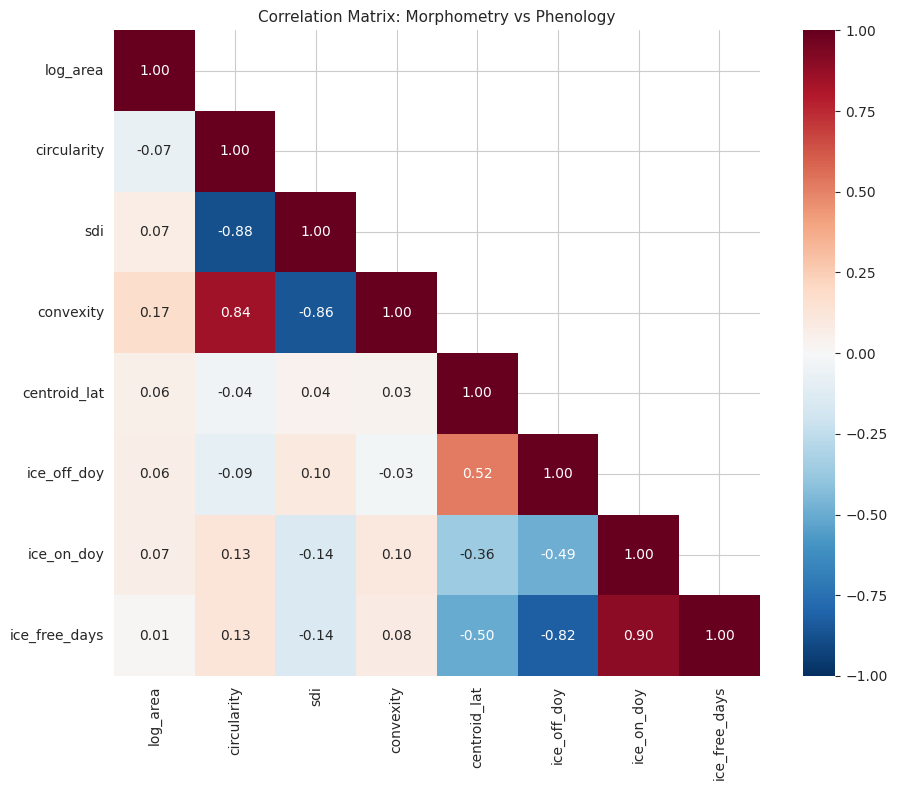

Saved: figures/supplementary/figS08_correlation_matrix.png


In [11]:
# Correlation matrix for all numeric variables
corr_vars = ['area_km2', 'circularity', 'sdi', 'convexity', 'centroid_lat',
             'ice_off_doy', 'ice_on_doy', 'ice_free_days']

# Use log area for better correlation
complete['log_area'] = np.log10(complete['area_km2'])
corr_vars_log = ['log_area', 'circularity', 'sdi', 'convexity', 'centroid_lat',
                 'ice_off_doy', 'ice_on_doy', 'ice_free_days']

corr_matrix = complete[corr_vars_log].corr()

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation Matrix: Morphometry vs Phenology')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/supplementary/figS08_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS08_correlation_matrix.png")

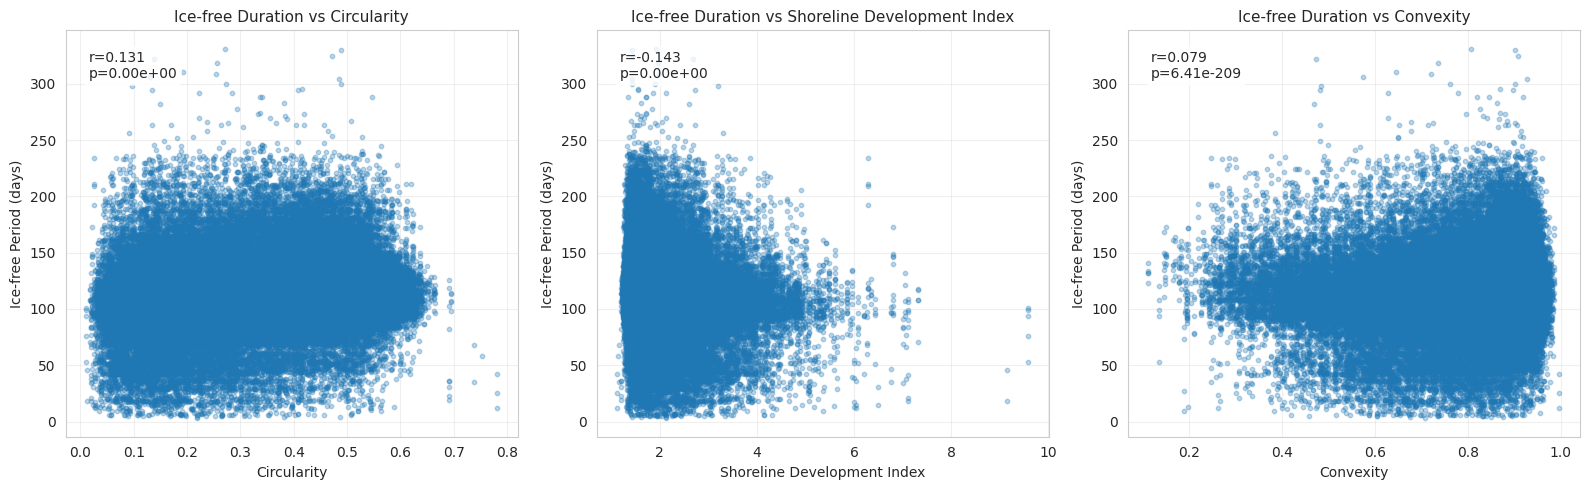

Saved: figures/supplementary/figS07_shape_phenology.png


In [12]:
# Shape metrics vs ice-free days
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

shape_vars = ['circularity', 'sdi', 'convexity']
shape_labels = ['Circularity', 'Shoreline Development Index', 'Convexity']

for i, (var, label) in enumerate(zip(shape_vars, shape_labels)):
    ax = axes[i]
    ax.scatter(complete[var], complete['ice_free_days'], alpha=0.3, s=10)
    
    # Add correlation
    mask = complete[var].notna() & complete['ice_free_days'].notna()
    r, p = stats.pearsonr(complete.loc[mask, var], complete.loc[mask, 'ice_free_days'])
    ax.text(0.05, 0.95, f'r={r:.3f}\np={p:.2e}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(label)
    ax.set_ylabel('Ice-free Period (days)')
    ax.set_title(f'Ice-free Duration vs {label}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/supplementary/figS07_shape_phenology.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS07_shape_phenology.png")

## Part 5: Inter-annual Variability

In [13]:
# Phenology statistics by year
years = complete['year'].unique()
print(f"Years in dataset: {sorted(years)}")

if len(years) > 1:
    year_summary = complete.groupby('year').agg({
        'ice_off_doy': ['mean', 'std', 'median', 'count'],
        'ice_on_doy': ['mean', 'std', 'median'],
        'ice_free_days': ['mean', 'std', 'median']
    }).round(1)

    print("\nPhenology Statistics by Year:")
    print("="*60)
    display(year_summary)
else:
    print(f"\nOnly single year ({years[0]}) in dataset - inter-annual analysis not applicable")
    print(f"\nPhenology Statistics for {years[0]}:")
    print(f"  Ice-off DOY: mean={complete['ice_off_doy'].mean():.1f}, std={complete['ice_off_doy'].std():.1f}")
    print(f"  Ice-on DOY:  mean={complete['ice_on_doy'].mean():.1f}, std={complete['ice_on_doy'].std():.1f}")
    if complete['ice_free_days'].notna().sum() > 0:
        print(f"  Ice-free:    mean={complete['ice_free_days'].mean():.1f}, std={complete['ice_free_days'].std():.1f}")

Years in dataset: [2019, 2020, 2021, 2022, 2023]

Phenology Statistics by Year:


ice_off_doy                     ice_on_doy              ice_free_days  \
            mean   std median  count       mean   std median          mean   
year                                                                         
2019       157.1  15.2  158.0  30116      279.2  16.9  278.0         122.0   
2020       158.2  12.3  158.0  30433      274.2  17.4  273.0         116.0   
2021       158.1  13.0  159.0  30367      266.2  16.2  265.0         108.1   
2022       164.3  10.1  165.0  30103      269.9  15.3  269.0         105.6   
2023       157.5  11.8  157.0  29923      274.8  14.0  274.0         117.3   

                   
       std median  
year               
2019  26.8  121.0  
2020  26.8  116.0  
2021  25.1  106.0  
2022  22.0  105.0  
2023  22.6  116.0

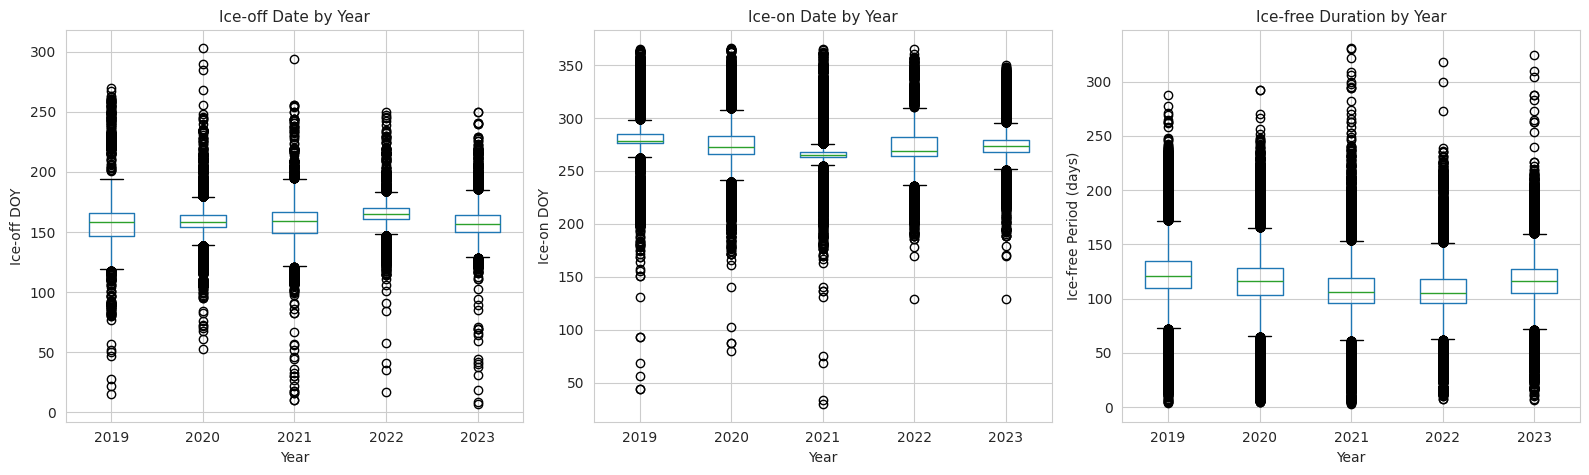

Saved: figures/supplementary/figS05_interannual_variability.png


In [14]:
# Box plots by year (or single year distribution)
years = complete['year'].unique()

if len(years) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Ice-off by year
    ax = axes[0]
    complete.boxplot(column='ice_off_doy', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-off DOY')
    ax.set_title('Ice-off Date by Year')
    plt.suptitle('')

    # Ice-on by year
    ax = axes[1]
    complete.boxplot(column='ice_on_doy', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-on DOY')
    ax.set_title('Ice-on Date by Year')
    plt.suptitle('')

    # Ice-free days by year
    ax = axes[2]
    complete.boxplot(column='ice_free_days', by='year', ax=ax)
    ax.set_xlabel('Year')
    ax.set_ylabel('Ice-free Period (days)')
    ax.set_title('Ice-free Duration by Year')
    plt.suptitle('')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/supplementary/figS05_interannual_variability.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: figures/supplementary/figS05_interannual_variability.png")
else:
    # Show distribution for single year
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    ax = axes[0]
    ax.hist(complete['ice_off_doy'].dropna(), bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Ice-off DOY')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-off Date Distribution ({years[0]})')
    ax.axvline(complete['ice_off_doy'].median(), color='red', linestyle='--', label=f"Median: {complete['ice_off_doy'].median():.0f}")
    ax.legend()
    
    ax = axes[1]
    ax.hist(complete['ice_on_doy'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.set_xlabel('Ice-on DOY')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-on Date Distribution ({years[0]})')
    ax.axvline(complete['ice_on_doy'].median(), color='red', linestyle='--', label=f"Median: {complete['ice_on_doy'].median():.0f}")
    ax.legend()
    
    ax = axes[2]
    ifd = complete['ice_free_days'].dropna()
    if len(ifd) > 0:
        ax.hist(ifd, bins=20, edgecolor='black', alpha=0.7, color='green')
        ax.axvline(ifd.median(), color='red', linestyle='--', label=f"Median: {ifd.median():.0f}")
        ax.legend()
    ax.set_xlabel('Ice-free Period (days)')
    ax.set_ylabel('Count')
    ax.set_title(f'Ice-free Duration Distribution ({years[0]})')
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/working/phenology_distributions_single_year.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: figures/working/phenology_distributions_single_year.png")

In [15]:
# Year-to-year consistency for individual lakes
years = complete['year'].unique()

if len(years) >= 3:
    # Calculate standard deviation of ice-free days for each lake across years
    lake_variability = complete.groupby('lake_id').agg({
        'ice_free_days': ['mean', 'std', 'count'],
        'area_km2': 'first',
        'centroid_lat': 'first'
    })
    lake_variability.columns = ['ice_free_mean', 'ice_free_std', 'n_years', 'area_km2', 'centroid_lat']
    lake_variability = lake_variability[lake_variability['n_years'] >= 3].copy()  # At least 3 years

    print(f"Lakes with ≥3 years of data: {len(lake_variability):,}")
    print(f"\nInter-annual variability (std of ice-free days):")
    print(f"  Mean:   {lake_variability['ice_free_std'].mean():.1f} days")
    print(f"  Median: {lake_variability['ice_free_std'].median():.1f} days")
    print(f"  Max:    {lake_variability['ice_free_std'].max():.1f} days")
else:
    print(f"Only {len(years)} year(s) in dataset - inter-annual variability analysis requires ≥3 years")
    print("\nShowing within-year variability statistics instead:")
    print(f"  Ice-off DOY std:   {complete['ice_off_doy'].std():.1f}")
    print(f"  Ice-on DOY std:    {complete['ice_on_doy'].std():.1f}")
    ifd = complete['ice_free_days'].dropna()
    if len(ifd) > 0:
        print(f"  Ice-free days std: {ifd.std():.1f}")

Lakes with ≥3 years of data: 30,336

Inter-annual variability (std of ice-free days):
  Mean:   12.7 days
  Median: 11.3 days
  Max:    121.4 days


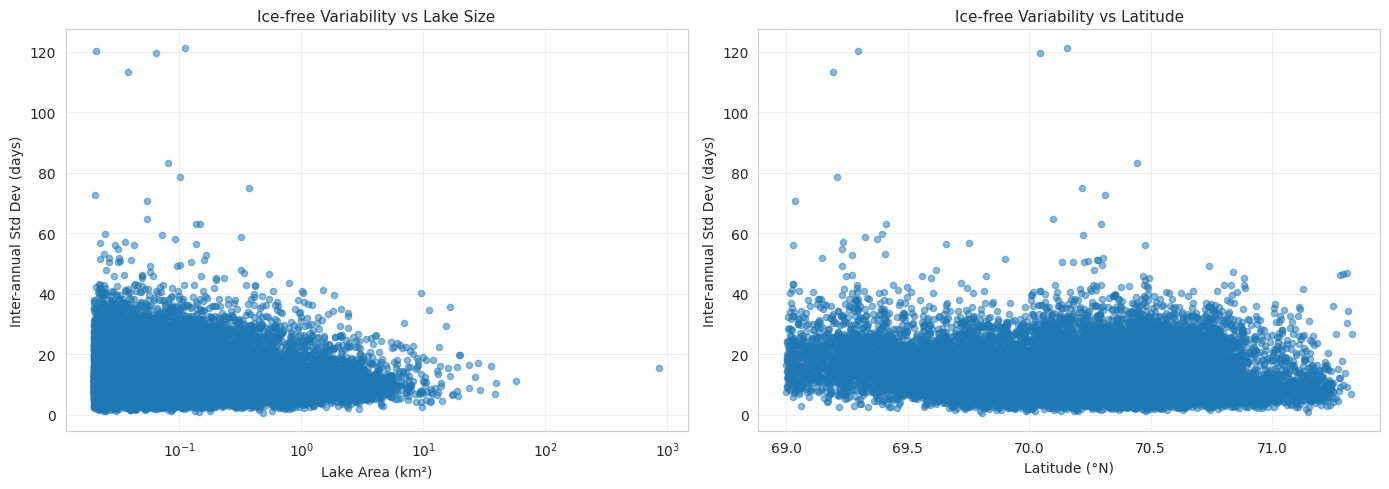

Saved: figures/working/interannual_variability_factors.png


In [16]:
# Plot variability vs lake characteristics
years = complete['year'].unique()

if len(years) >= 3 and 'lake_variability' in dir() and len(lake_variability) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Variability vs size
    ax = axes[0]
    ax.scatter(lake_variability['area_km2'], lake_variability['ice_free_std'], alpha=0.5, s=20)
    ax.set_xscale('log')
    ax.set_xlabel('Lake Area (km²)')
    ax.set_ylabel('Inter-annual Std Dev (days)')
    ax.set_title('Ice-free Variability vs Lake Size')
    ax.grid(True, alpha=0.3)

    # Variability vs latitude
    ax = axes[1]
    ax.scatter(lake_variability['centroid_lat'], lake_variability['ice_free_std'], alpha=0.5, s=20)
    ax.set_xlabel('Latitude (°N)')
    ax.set_ylabel('Inter-annual Std Dev (days)')
    ax.set_title('Ice-free Variability vs Latitude')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/working/interannual_variability_factors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: figures/working/interannual_variability_factors.png")
else:
    # Show within-year relationships with single year data
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Ice-free days vs size
    ax = axes[0]
    ifd_valid = complete[complete['ice_free_days'].notna()]
    if len(ifd_valid) > 0:
        ax.scatter(ifd_valid['area_km2'], ifd_valid['ice_free_days'], alpha=0.5, s=30)
        ax.set_xscale('log')
        ax.set_xlabel('Lake Area (km²)')
        ax.set_ylabel('Ice-free Days')
        ax.set_title('Ice-free Duration vs Lake Size')
        ax.grid(True, alpha=0.3)
    
    # Ice-free days vs latitude
    ax = axes[1]
    if len(ifd_valid) > 0:
        ax.scatter(ifd_valid['centroid_lat'], ifd_valid['ice_free_days'], alpha=0.5, s=30)
        ax.set_xlabel('Latitude (°N)')
        ax.set_ylabel('Ice-free Days')
        ax.set_title('Ice-free Duration vs Latitude')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/working/ice_free_vs_characteristics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: figures/working/ice_free_vs_characteristics.png")

## Part 6: Spatial Patterns

In [17]:
# Aggregate by lake (mean across years)
lake_mean = complete.groupby('lake_id').agg({
    'centroid_lon': 'first',
    'centroid_lat': 'first',
    'area_km2': 'first',
    'ice_off_doy': 'mean',
    'ice_on_doy': 'mean',
    'ice_free_days': 'mean'
}).reset_index()

print(f"Aggregated {len(lake_mean):,} lakes")

Aggregated 30,725 lakes


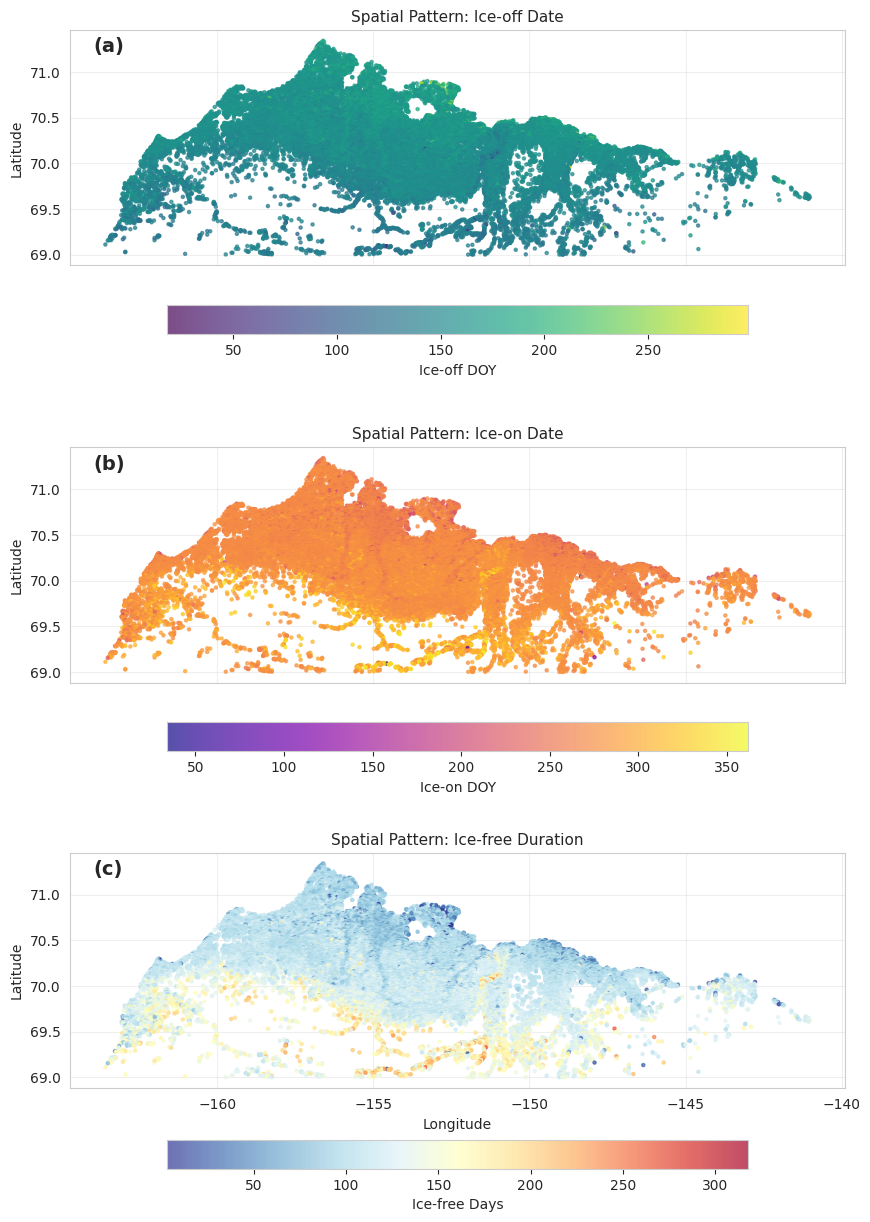

Saved: figures/manuscript/fig03_spatial_phenology_maps.png


In [18]:
# Spatial maps of phenology — vertical 3x1 layout
aspect_ratio = np.cos(np.radians(70))

fig, axes = plt.subplots(3, 1, figsize=(10, 16))

panels = [
    (axes[0], 'ice_off_doy', 'viridis', 'Ice-off DOY', 'Spatial Pattern: Ice-off Date', '(a)'),
    (axes[1], 'ice_on_doy', 'plasma', 'Ice-on DOY', 'Spatial Pattern: Ice-on Date', '(b)'),
    (axes[2], 'ice_free_days', 'RdYlBu_r', 'Ice-free Days', 'Spatial Pattern: Ice-free Duration', '(c)'),
]

for i, (ax, col, cmap, cbar_label, title, panel_label) in enumerate(panels):
    scatter = ax.scatter(lake_mean['centroid_lon'], lake_mean['centroid_lat'],
                         c=lake_mean[col], cmap=cmap, s=5, alpha=0.7)
    cbar_pad = 0.13 if i == 2 else 0.10
    plt.colorbar(scatter, ax=ax, label=cbar_label, orientation='horizontal', shrink=0.75, pad=cbar_pad)
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.set_aspect(1/aspect_ratio)
    ax.grid(True, alpha=0.3)
    ax.text(0.03, 0.97, panel_label, transform=ax.transAxes, fontsize=14,
            fontweight='bold', va='top', ha='left')
    # Only show Longitude label on bottom panel
    if i < 2:
        ax.set_xticklabels([])
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Longitude')

plt.subplots_adjust(hspace=0.05)
plt.savefig('./figures/manuscript/fig03_spatial_phenology_maps.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/manuscript/fig03_spatial_phenology_maps.png")

## Part 7: Temperature-Controlled Regression Analysis

Assess how much of ice phenology variance is explained by temperature vs morphometry.
This controls for the confounding effect of temperature when evaluating morphometry impacts.

## Confounding Check: Morphometry vs Temperature/Location

Before regression analysis, check whether morphometry variables are correlated with temperature or location.
If morphometry is confounded with location/temperature, regression coefficients may be biased.

In [19]:
# Check correlations between morphometry and temperature/location
# These would indicate potential confounding in the regression analysis
# NOTE: This cell requires ERA5 data which is loaded later in ADDT analysis
# Skip if mean_spring_temp is not yet available

morph_vars = ['log_area', 'sdi', 'circularity', 'convexity']
location_vars = ['centroid_lat', 'centroid_lon']

# Check if mean_spring_temp is available (it's computed in ADDT analysis cell)
if 'mean_spring_temp' not in dir():
    print("="*70)
    print("CONFOUNDING CHECK: Skipped")
    print("="*70)
    print("\nNOTE: This analysis requires ERA5 temperature data.")
    print("Run the ADDT analysis cell first, or see confounding results below in that section.")
else:
    # Compute mean spring temperature per lake (across years)
    lake_temp = complete.merge(mean_spring_temp, on=['lake_id', 'year'], how='inner')
    lake_temp_mean = lake_temp.groupby('lake_id').agg({
        'mean_spring_temp': 'mean',
        'centroid_lat': 'first',
        'centroid_lon': 'first',
        'log_area': 'first',
        'sdi': 'first',
        'circularity': 'first',
        'convexity': 'first'
    }).reset_index()
    
    print("="*70)
    print("CONFOUNDING CHECK: Morphometry vs Temperature/Location")
    print("="*70)
    print("\nCorrelations between morphometry and potential confounders:")
    print("-"*70)
    
    # Build correlation table
    confound_corrs = []
    for morph in morph_vars:
        row = {'Morphometry': morph}
        
        # Correlation with temperature
        mask = lake_temp_mean[morph].notna() & lake_temp_mean['mean_spring_temp'].notna()
        r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'mean_spring_temp'])
        row['vs Temperature'] = f"r={r:+.3f}"
        
        # Correlation with latitude
        mask = lake_temp_mean[morph].notna() & lake_temp_mean['centroid_lat'].notna()
        r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'centroid_lat'])
        row['vs Latitude'] = f"r={r:+.3f}"
        
        # Correlation with longitude
        mask = lake_temp_mean[morph].notna() & lake_temp_mean['centroid_lon'].notna()
        r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'centroid_lon'])
        row['vs Longitude'] = f"r={r:+.3f}"
        
        confound_corrs.append(row)
    
    confound_df = pd.DataFrame(confound_corrs)
    display(confound_df.set_index('Morphometry'))
    
    # Check temperature-latitude correlation (known confounder)
    mask = lake_temp_mean['mean_spring_temp'].notna() & lake_temp_mean['centroid_lat'].notna()
    r_temp_lat, _ = stats.pearsonr(lake_temp_mean.loc[mask, 'centroid_lat'], 
                                    lake_temp_mean.loc[mask, 'mean_spring_temp'])
    print(f"\nTemperature-Latitude correlation: r = {r_temp_lat:.3f}")
    
    print("\n" + "-"*70)
    print("INTERPRETATION:")
    print("-"*70)
    print("""
• |r| < 0.1: Negligible confounding
• 0.1 ≤ |r| < 0.3: Weak confounding (interpret with caution)
• |r| ≥ 0.3: Moderate-strong confounding (temperature control essential)

If morphometry is uncorrelated with temperature/location, regression 
coefficients for morphometry are unlikely to be biased by spatial confounding.
""")

CONFOUNDING CHECK: Skipped

NOTE: This analysis requires ERA5 temperature data.
Run the ADDT analysis cell first, or see confounding results below in that section.


## ADDT/ADDF Analysis\n\nAccumulated Degree Days analysis to understand temperature controls on phenology timing.

ACCUMULATED DEGREE DAY ANALYSIS (ADDT/ADDF switching)

Loading ERA5 temperature data...


ERA5 data loaded: 56,803,208 observations


Temperature range: -48.8°C to 24.3°C



Applying ADDT/ADDF switching to 31,108 lakes...
(continuous 5-year time series per lake, 7-day switching window)


Completed in 87.7 seconds

ADDT/ADDF calculated for 150,942 lake-years

ADDT statistics (at ice-off):
  Mean: 60.5 degree-days
  Std:  56.2 degree-days
  Range: 0.0 to 985.1

ADDF statistics (at ice-on):
  Mean: 27.5 degree-days
  Std:  101.0 degree-days
  Range: 0.0 to 4440.1

Max ice thickness statistics (Stefan equation, alpha=2.0):
  Mean: 121.2 cm
  Std:  15.9 cm
  Range: 78.2 to 143.0 cm

ADDT/ADDF SWITCHING vs SAR PHENOLOGY COMPARISON

Thaw onset comparison (n=150,942):
  ADDT thaw DOY:  mean=156, median=160


  SAR ice-off DOY:  mean=159, median=160
  Offset (SAR - ADDT/ADDF): mean=3.4, median=4.0, std=13.2 days
  Pearson r = 0.263 (p = 0.00e+00)
  Within +/-7 days: 47.0%
  Within +/-14 days: 74.8%
  Within +/-21 days: 90.8%

Freeze onset comparison (n=150,942):
  ADDF freeze DOY: mean=279, median=280
  SAR ice-on DOY:    mean=273, median=272
  Offset (SAR - ADDT/ADDF): mean=-5.9, median=-6.0, std=17.1 days
  Pearson r = 0.174 (p = 0.00e+00)
  Within +/-7 days: 44.7%
  Within +/-14 days: 74.6%
  Within +/-21 days: 85.7%


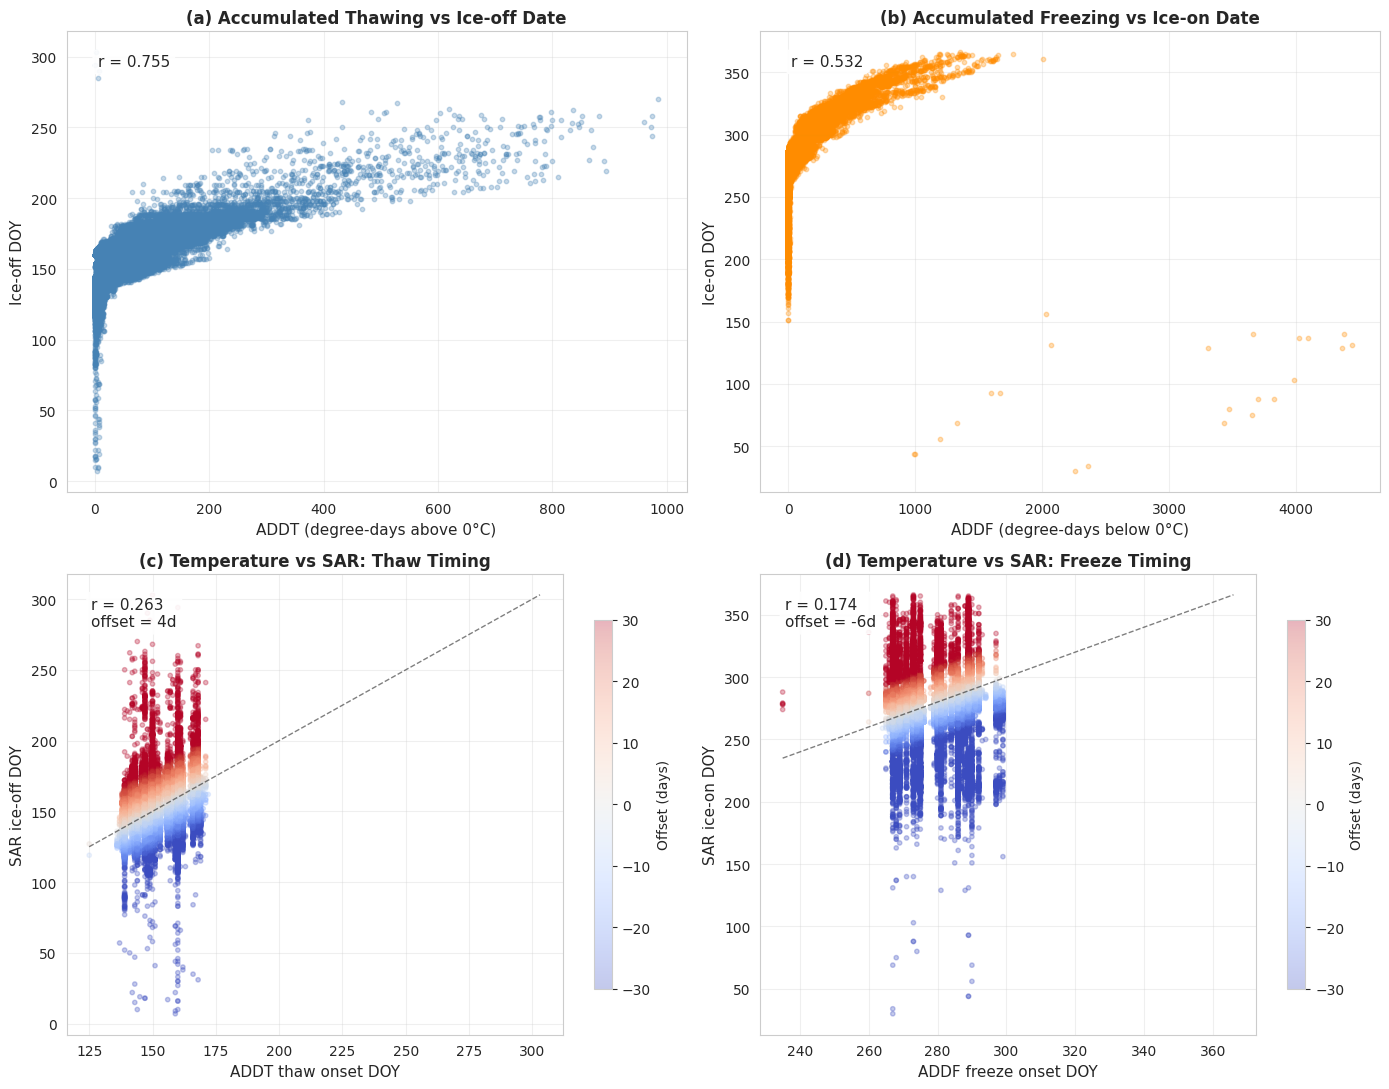

Saved: figure_data/addt_analysis.csv


In [20]:
# ============================================================
# ACCUMULATED DEGREE DAY ANALYSIS (ADDT/ADDF-style ADDT/ADDF)
# ============================================================
# ADDT/ADDF continuous accumulation with 7-day switching:
# - ADDT/ADDF accumulate continuously across the full 2019-2023 time series
# - When the active metric stalls for 7+ days, the stalled metric resets
#   and the system switches to the other metric
# - Ice thickness estimated via Stefan equation: h = alpha * sqrt(ADDF)
# - Switching transition dates compared against SAR-detected phenology

print("="*70)
print("ACCUMULATED DEGREE DAY ANALYSIS (ADDT/ADDF switching)")
print("="*70)

# Load ERA5 daily temperatures for all lakes/years
from google.cloud import storage
import warnings
warnings.filterwarnings('ignore')

BUCKET_NAME = 'wustl-eeps-geospatial'
EXPORT_PREFIX = 'thermokarst_lakes/exports'
YEARS = [2019, 2020, 2021, 2022, 2023]

print("\nLoading ERA5 temperature data...")
era5_chunks = []
for year in YEARS:
    for chunk_id in range(21):
        try:
            chunk_path = f'gs://{BUCKET_NAME}/{EXPORT_PREFIX}/{year}/chunk_{chunk_id:02d}/era5_data.csv'
            chunk = pd.read_csv(chunk_path)
            chunk['year'] = year
            era5_chunks.append(chunk)
        except FileNotFoundError:
            continue

if len(era5_chunks) == 0:
    raise FileNotFoundError('No ERA5 chunk files could be loaded')
expected_chunks = len(YEARS) * 21
if len(era5_chunks) < expected_chunks:
    print(f'WARNING: Loaded {len(era5_chunks)}/{expected_chunks} ERA5 chunks')
era5 = pd.concat(era5_chunks, ignore_index=True)
era5 = era5.rename(columns={'id': 'lake_id'})
era5['era5_date'] = pd.to_datetime(era5['era5_date'])
era5['doy'] = era5['era5_date'].dt.dayofyear

print(f"ERA5 data loaded: {len(era5):,} observations")
print(f"Temperature range: {era5['temp_c'].min():.1f}°C to {era5['temp_c'].max():.1f}°C")

# ----------------------------------------------------------
# ADDT/ADDF switching function
# ----------------------------------------------------------
SWITCH_WINDOW = 7    # Days without growth before switching active metric
ALPHA = 2.0          # Stefan equation coefficient (cm / sqrt(degree-day))

def addt_addf_switching(temps, window_size=SWITCH_WINDOW):
    """ADDT/ADDF continuous ADDT/ADDF with 7-day switching.

    Args:
        temps: array of daily temperatures (C), sorted chronologically
        window_size: days without growth before switching active metric

    Returns:
        addt_series, addf_series, ice_thickness_series, active_series:
            arrays same length as temps. active_series: 0=ADDF, 1=ADDT.
    """
    n = len(temps)
    addt_series = np.empty(n)
    addf_series = np.empty(n)
    ice_series = np.empty(n)
    active_series = np.empty(n, dtype=np.int8)

    addt_cum = 0.0
    addf_cum = 0.0
    stagnant = 0
    active = 0  # 0 = ADDF (freezing), 1 = ADDT (thawing)

    for i in range(n):
        t = temps[i]

        # Accumulate
        if t > 0:
            addt_cum += t
        elif t < 0:
            addf_cum += (-t)

        # Stagnation check: did the active metric grow today?
        if active == 1 and t > 0:
            stagnant = 0
        elif active == 0 and t < 0:
            stagnant = 0
        else:
            stagnant += 1

        # Switching: reset the STALLED (old active) metric
        if stagnant >= window_size:
            if active == 1:       # ADDT stalled -> switch to ADDF
                addt_cum = 0.0
                active = 0
            else:                 # ADDF stalled -> switch to ADDT
                addf_cum = 0.0
                active = 1
            stagnant = 0

        addt_series[i] = addt_cum
        addf_series[i] = addf_cum
        active_series[i] = active

        # Ice thickness (Stefan equation)
        if active == 0:  # Freezing active
            ice_series[i] = max(0.0, ALPHA * np.sqrt(addf_cum))
        else:            # Thawing active
            ice_series[i] = 0.0

    return addt_series, addf_series, ice_series, active_series

# ----------------------------------------------------------
# Build phenology lookup and apply switching across all lakes
# ----------------------------------------------------------
pheno_lookup = complete.set_index(['lake_id', 'year'])[
    ['ice_off_doy', 'ice_on_doy']
].to_dict('index')

# Sort ERA5 for continuous time series per lake
era5_sorted = era5.sort_values(['lake_id', 'era5_date'])

print(f"\nApplying ADDT/ADDF switching to {era5_sorted['lake_id'].nunique():,} lakes...")
print(f"(continuous 5-year time series per lake, {SWITCH_WINDOW}-day switching window)")
import time
t0 = time.time()

def thermal_onsets_principal(yr_doys, yr_active):
    """Thaw/freeze onset DOY from the longest thawing run (no calendar gate).

    Parameters
    ----------
    yr_doys : np.ndarray   day-of-year for each day in the year slice
    yr_active : np.ndarray  1 = thawing active, 0 = freezing active (from the
                            existing ADDT/ADDF switching series, sliced to the year)

    Returns
    -------
    (thaw_doy, freeze_doy) : floats (np.nan if not determinable)
    """
    a = np.asarray(yr_active).astype(int)
    n = len(a)
    runs, i = [], 0
    while i < n:
        if a[i] == 1:
            j = i
            while j + 1 < n and a[j + 1] == 1:
                j += 1
            runs.append((i, j))
            i = j + 1
        else:
            i += 1
    if not runs:
        return np.nan, np.nan
    s, e = max(runs, key=lambda r: r[1] - r[0])          # longest thawing run
    thaw_doy = float(yr_doys[s])
    freeze_doy = float(yr_doys[e + 1]) if e + 1 < n else np.nan  # end of warm season
    return thaw_doy, freeze_doy

results = []
for lake_id, lake_era5 in era5_sorted.groupby('lake_id'):
    temps = lake_era5['temp_c'].values
    doys = lake_era5['era5_date'].dt.dayofyear.values
    years = lake_era5['year'].values

    addt_s, addf_s, ice_s, active_s = addt_addf_switching(temps)

    # Extract per-year values at phenology dates
    for yr in YEARS:
        key = (lake_id, yr)
        if key not in pheno_lookup:
            continue
        pheno = pheno_lookup[key]
        if pd.isna(pheno['ice_off_doy']) or pd.isna(pheno['ice_on_doy']):
            continue

        yr_mask = (years == yr)
        yr_doys = doys[yr_mask]
        yr_addt = addt_s[yr_mask]
        yr_addf = addf_s[yr_mask]
        yr_ice = ice_s[yr_mask]
        yr_active = active_s[yr_mask]

        ice_off_doy = int(pheno['ice_off_doy'])
        ice_on_doy = int(pheno['ice_on_doy'])

        # Find matching DOY indices for ADDT/ADDF sampling
        off_match = np.where(yr_doys == ice_off_doy)[0]
        on_match = np.where(yr_doys == ice_on_doy)[0]

        if len(off_match) == 0 or len(on_match) == 0:
            continue

        # Thaw/freeze onset from the longest contiguous thawing run (principal
        # warm season). Independent of the SAR phenology window, so the
        # SAR-vs-temperature comparison is not circular.
        addt_thaw_doy, addf_freeze_doy = thermal_onsets_principal(yr_doys, yr_active)
        results.append({
            'lake_id': lake_id,
            'year': yr,
            'addt': yr_addt[off_match[0]],
            'addf': yr_addf[on_match[0]],
            'ice_thickness_max_cm': yr_ice.max(),
            'addt_thaw_doy': addt_thaw_doy,
            'addf_freeze_doy': addf_freeze_doy,
        })

elapsed = time.time() - t0
print(f"Completed in {elapsed:.1f} seconds")

# ----------------------------------------------------------
# Merge with phenology data and report statistics
# ----------------------------------------------------------
addt_df = pd.DataFrame(results)
addt_analysis = complete.merge(addt_df, on=['lake_id', 'year'], how='left')

# Compute offsets (positive = SAR later than ADDT/ADDF)
addt_analysis['thaw_offset'] = addt_analysis['ice_off_doy'] - addt_analysis['addt_thaw_doy']
addt_analysis['freeze_offset'] = addt_analysis['ice_on_doy'] - addt_analysis['addf_freeze_doy']

print(f"\nADDT/ADDF calculated for {addt_analysis['addt'].notna().sum():,} lake-years")

print(f"\nADDT statistics (at ice-off):")
print(f"  Mean: {addt_analysis['addt'].mean():.1f} degree-days")
print(f"  Std:  {addt_analysis['addt'].std():.1f} degree-days")
print(f"  Range: {addt_analysis['addt'].min():.1f} to {addt_analysis['addt'].max():.1f}")

print(f"\nADDF statistics (at ice-on):")
print(f"  Mean: {addt_analysis['addf'].mean():.1f} degree-days")
print(f"  Std:  {addt_analysis['addf'].std():.1f} degree-days")
print(f"  Range: {addt_analysis['addf'].min():.1f} to {addt_analysis['addf'].max():.1f}")

print(f"\nMax ice thickness statistics (Stefan equation, alpha={ALPHA}):")
print(f"  Mean: {addt_analysis['ice_thickness_max_cm'].mean():.1f} cm")
print(f"  Std:  {addt_analysis['ice_thickness_max_cm'].std():.1f} cm")
print(f"  Range: {addt_analysis['ice_thickness_max_cm'].min():.1f} to {addt_analysis['ice_thickness_max_cm'].max():.1f} cm")

# ----------------------------------------------------------
# ADDT/ADDF vs SAR comparison statistics
# ----------------------------------------------------------
print("\n" + "="*70)
print("ADDT/ADDF SWITCHING vs SAR PHENOLOGY COMPARISON")
print("="*70)

# Thaw comparison
thaw_valid = addt_analysis['addt_thaw_doy'].notna() & addt_analysis['ice_off_doy'].notna()
n_thaw = thaw_valid.sum()
thaw_off = addt_analysis.loc[thaw_valid, 'thaw_offset']
print(f"\nThaw onset comparison (n={n_thaw:,}):")
print(f"  ADDT thaw DOY:  mean={addt_analysis.loc[thaw_valid, 'addt_thaw_doy'].mean():.0f}, "
      f"median={addt_analysis.loc[thaw_valid, 'addt_thaw_doy'].median():.0f}")
print(f"  SAR ice-off DOY:  mean={addt_analysis.loc[thaw_valid, 'ice_off_doy'].mean():.0f}, "
      f"median={addt_analysis.loc[thaw_valid, 'ice_off_doy'].median():.0f}")
print(f"  Offset (SAR - ADDT/ADDF): mean={thaw_off.mean():.1f}, median={thaw_off.median():.1f}, "
      f"std={thaw_off.std():.1f} days")
r_thaw, p_thaw = stats.pearsonr(addt_analysis.loc[thaw_valid, 'addt_thaw_doy'],
                                 addt_analysis.loc[thaw_valid, 'ice_off_doy'])
print(f"  Pearson r = {r_thaw:.3f} (p = {p_thaw:.2e})")
for window in [7, 14, 21]:
    agree = (thaw_off.abs() <= window).mean() * 100
    print(f"  Within +/-{window} days: {agree:.1f}%")

# Freeze comparison
freeze_valid = addt_analysis['addf_freeze_doy'].notna() & addt_analysis['ice_on_doy'].notna()
n_freeze = freeze_valid.sum()
freeze_off = addt_analysis.loc[freeze_valid, 'freeze_offset']
print(f"\nFreeze onset comparison (n={n_freeze:,}):")
print(f"  ADDF freeze DOY: mean={addt_analysis.loc[freeze_valid, 'addf_freeze_doy'].mean():.0f}, "
      f"median={addt_analysis.loc[freeze_valid, 'addf_freeze_doy'].median():.0f}")
print(f"  SAR ice-on DOY:    mean={addt_analysis.loc[freeze_valid, 'ice_on_doy'].mean():.0f}, "
      f"median={addt_analysis.loc[freeze_valid, 'ice_on_doy'].median():.0f}")
print(f"  Offset (SAR - ADDT/ADDF): mean={freeze_off.mean():.1f}, median={freeze_off.median():.1f}, "
      f"std={freeze_off.std():.1f} days")
r_freeze, p_freeze = stats.pearsonr(addt_analysis.loc[freeze_valid, 'addf_freeze_doy'],
                                     addt_analysis.loc[freeze_valid, 'ice_on_doy'])
print(f"  Pearson r = {r_freeze:.3f} (p = {p_freeze:.2e})")
for window in [7, 14, 21]:
    agree = (freeze_off.abs() <= window).mean() * 100
    print(f"  Within +/-{window} days: {agree:.1f}%")

# Missing transition dates
n_no_thaw = addt_analysis['addt_thaw_doy'].isna().sum()
n_no_freeze = addt_analysis['addf_freeze_doy'].isna().sum()
if n_no_thaw > 0 or n_no_freeze > 0:
    print(f"\nMissing transitions: {n_no_thaw:,} lake-years without thaw transition, "
          f"{n_no_freeze:,} without freeze transition")

# ----------------------------------------------------------
# 4-panel figure: ADDT/ADDF + ADDT/ADDF vs SAR comparison
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel (a): ADDT vs Ice-off DOY
ax = axes[0, 0]
valid = addt_analysis['addt'].notna() & addt_analysis['ice_off_doy'].notna()
ax.scatter(addt_analysis.loc[valid, 'addt'], addt_analysis.loc[valid, 'ice_off_doy'],
           alpha=0.3, s=10, c='steelblue')
r, p = stats.pearsonr(addt_analysis.loc[valid, 'addt'], addt_analysis.loc[valid, 'ice_off_doy'])
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.set_xlabel('ADDT (degree-days above 0°C)', fontsize=11)
ax.set_ylabel('Ice-off DOY', fontsize=11)
ax.set_title('(a) Accumulated Thawing vs Ice-off Date', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel (b): ADDF vs Ice-on DOY
ax = axes[0, 1]
valid = addt_analysis['addf'].notna() & addt_analysis['ice_on_doy'].notna()
ax.scatter(addt_analysis.loc[valid, 'addf'], addt_analysis.loc[valid, 'ice_on_doy'],
           alpha=0.3, s=10, c='darkorange')
r, p = stats.pearsonr(addt_analysis.loc[valid, 'addf'], addt_analysis.loc[valid, 'ice_on_doy'])
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.set_xlabel('ADDF (degree-days below 0°C)', fontsize=11)
ax.set_ylabel('Ice-on DOY', fontsize=11)
ax.set_title('(b) Accumulated Freezing vs Ice-on Date', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel (c): ADDT thaw onset DOY vs SAR ice-off DOY
ax = axes[1, 0]
valid_c = thaw_valid
sc = ax.scatter(addt_analysis.loc[valid_c, 'addt_thaw_doy'],
                addt_analysis.loc[valid_c, 'ice_off_doy'],
                alpha=0.3, s=10, c=addt_analysis.loc[valid_c, 'thaw_offset'],
                cmap='coolwarm', vmin=-30, vmax=30)
# 1:1 line
lims = [addt_analysis.loc[valid_c, 'addt_thaw_doy'].min(),
        addt_analysis.loc[valid_c, 'ice_off_doy'].max()]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
ax.text(0.05, 0.95, f'r = {r_thaw:.3f}\noffset = {thaw_off.median():.0f}d',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.set_xlabel('ADDT thaw onset DOY', fontsize=11)
ax.set_ylabel('SAR ice-off DOY', fontsize=11)
ax.set_title('(c) Temperature vs SAR: Thaw Timing', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Offset (days)', shrink=0.8)

# Panel (d): ADDF freeze onset DOY vs SAR ice-on DOY
ax = axes[1, 1]
valid_d = freeze_valid
sc = ax.scatter(addt_analysis.loc[valid_d, 'addf_freeze_doy'],
                addt_analysis.loc[valid_d, 'ice_on_doy'],
                alpha=0.3, s=10, c=addt_analysis.loc[valid_d, 'freeze_offset'],
                cmap='coolwarm', vmin=-30, vmax=30)
lims = [addt_analysis.loc[valid_d, 'addf_freeze_doy'].min(),
        addt_analysis.loc[valid_d, 'ice_on_doy'].max()]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
ax.text(0.05, 0.95, f'r = {r_freeze:.3f}\noffset = {freeze_off.median():.0f}d',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.set_xlabel('ADDF freeze onset DOY', fontsize=11)
ax.set_ylabel('SAR ice-on DOY', fontsize=11)
ax.set_title('(d) Temperature vs SAR: Freeze Timing', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Offset (days)', shrink=0.8)

plt.tight_layout()
plt.show()

# Export ADDT/ADDF data with ADDT/ADDF comparison columns
export_cols = ['lake_id', 'year', 'ice_off_doy', 'ice_on_doy', 'ice_free_days',
               'addt', 'addf', 'ice_thickness_max_cm',
               'addt_thaw_doy', 'addf_freeze_doy', 'thaw_offset', 'freeze_offset',
               'area_km2', 'centroid_lat']
addt_analysis[export_cols].to_csv('figure_data/addt_analysis.csv', index=False)

print("Saved: figure_data/addt_analysis.csv")

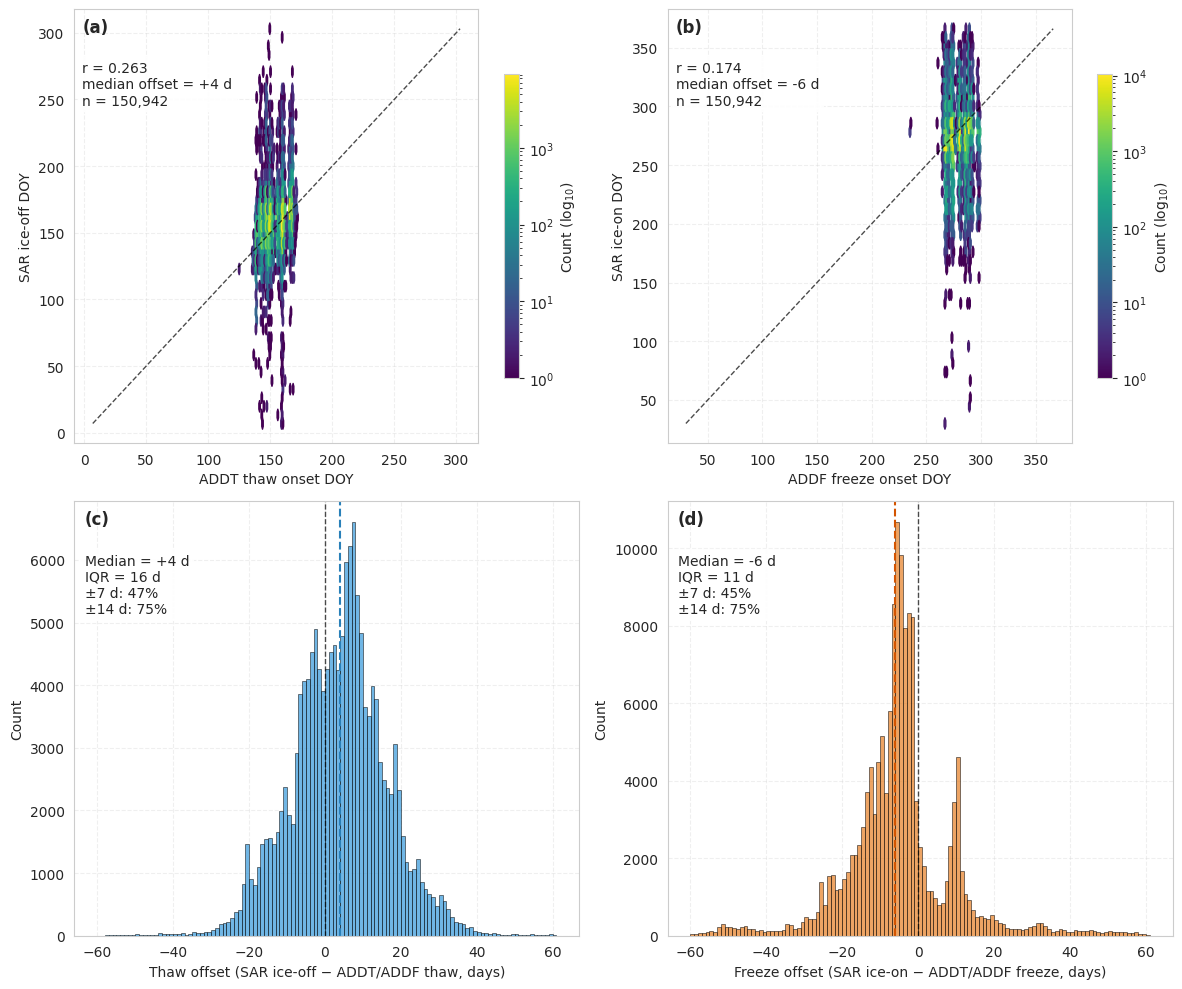

Saved: figures/supplementary/figS12_addt_sar_comparison.png


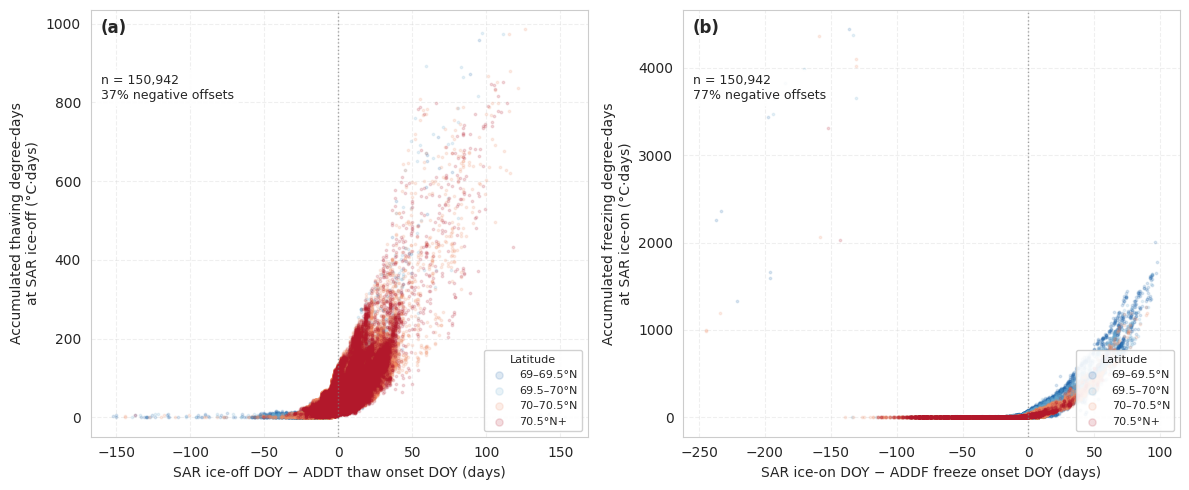

Saved: figures/supplementary/figS17_energy_offset.png


Saved: figure_data/figS17_energy_offset.csv (150,942 rows)


In [21]:
# ============================================================
# ADDT/ADDF vs SAR Phenology — shared data prep
# ============================================================

from matplotlib.colors import LogNorm

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

# --- Prepare data ---
thaw_mask = addt_analysis['addt_thaw_doy'].notna() & addt_analysis['ice_off_doy'].notna()
freeze_mask = addt_analysis['addf_freeze_doy'].notna() & addt_analysis['ice_on_doy'].notna()

addt_thaw = addt_analysis.loc[thaw_mask, 'addt_thaw_doy'].values
sar_off = addt_analysis.loc[thaw_mask, 'ice_off_doy'].values
thaw_off = addt_analysis.loc[thaw_mask, 'thaw_offset'].values
addt_at_off = addt_analysis.loc[thaw_mask, 'addt'].values

addf_freeze = addt_analysis.loc[freeze_mask, 'addf_freeze_doy'].values
sar_on = addt_analysis.loc[freeze_mask, 'ice_on_doy'].values
freeze_off = addt_analysis.loc[freeze_mask, 'freeze_offset'].values
addf_at_on = addt_analysis.loc[freeze_mask, 'addf'].values

# Correlation statistics
r_thaw_doy, _ = stats.pearsonr(addt_thaw, sar_off)
r_freeze_doy, _ = stats.pearsonr(addf_freeze, sar_on)
r_thaw_addt, _ = stats.pearsonr(addt_at_off, thaw_off)
r_freeze_addf, _ = stats.pearsonr(addf_at_on, freeze_off)

# ============================================================
# SUPPLEMENTARY FIGURE S12: DOY Agreement + Offset Distributions
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Thaw: ADDT thaw onset DOY vs SAR ice-off DOY
ax = axes[0, 0]
hb = ax.hexbin(addt_thaw, sar_off, gridsize=40, cmap='viridis',
               norm=LogNorm(), mincnt=1)
doy_min = min(addt_thaw.min(), sar_off.min())
doy_max = max(addt_thaw.max(), sar_off.max())
ax.plot([doy_min, doy_max], [doy_min, doy_max], 'k--', linewidth=1, alpha=0.7)
ax.set_xlabel('ADDT thaw onset DOY')
ax.set_ylabel('SAR ice-off DOY')
ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')
ax.text(0.02, 0.88, f'r = {r_thaw_doy:.3f}\nmedian offset = +{np.median(thaw_off):.0f} d\nn = {len(thaw_off):,}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
ax.grid(True, alpha=0.3, linestyle='--')
cb = plt.colorbar(hb, ax=ax, shrink=0.7)
cb.set_label(r'Count (log$_{10}$)')

# (b) Freeze: ADDF freeze onset DOY vs SAR ice-on DOY
ax = axes[0, 1]
hb = ax.hexbin(addf_freeze, sar_on, gridsize=40, cmap='viridis',
               norm=LogNorm(), mincnt=1)
doy_min = min(addf_freeze.min(), sar_on.min())
doy_max = max(addf_freeze.max(), sar_on.max())
ax.plot([doy_min, doy_max], [doy_min, doy_max], 'k--', linewidth=1, alpha=0.7)
ax.set_xlabel('ADDF freeze onset DOY')
ax.set_ylabel('SAR ice-on DOY')
ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')
ax.text(0.02, 0.88, f'r = {r_freeze_doy:.3f}\nmedian offset = {np.median(freeze_off):.0f} d\nn = {len(freeze_off):,}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
ax.grid(True, alpha=0.3, linestyle='--')
cb = plt.colorbar(hb, ax=ax, shrink=0.7)
cb.set_label(r'Count (log$_{10}$)')

# (c) Thaw offset histogram
ax = axes[1, 0]
thaw_clipped = thaw_off[(thaw_off >= -60) & (thaw_off <= 60)]
bins_thaw = np.arange(-60, 62, 1)
ax.hist(thaw_clipped, bins=bins_thaw, color='#3498db', alpha=0.7,
        edgecolor='black', linewidth=0.5)
med_thaw = np.median(thaw_off)
ax.axvline(med_thaw, color='#2980b9', linestyle='--', linewidth=1.5)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
iqr_thaw = np.percentile(thaw_off, 75) - np.percentile(thaw_off, 25)
within_7 = np.mean(np.abs(thaw_off) <= 7) * 100
within_14 = np.mean(np.abs(thaw_off) <= 14) * 100
ax.set_xlabel('Thaw offset (SAR ice-off \u2212 ADDT/ADDF thaw, days)')
ax.set_ylabel('Count')
ax.text(0.02, 0.98, '(c)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')
ax.text(0.02, 0.88, f'Median = {med_thaw:+.0f} d\nIQR = {iqr_thaw:.0f} d\n'
        f'\u00b17 d: {within_7:.0f}%\n\u00b114 d: {within_14:.0f}%',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
ax.grid(True, alpha=0.3, linestyle='--')

# (d) Freeze offset histogram
ax = axes[1, 1]
freeze_clipped = freeze_off[(freeze_off >= -60) & (freeze_off <= 60)]
bins_freeze = np.arange(-60, 62, 1)
ax.hist(freeze_clipped, bins=bins_freeze, color='#e67e22', alpha=0.7,
        edgecolor='black', linewidth=0.5)
med_freeze = np.median(freeze_off)
ax.axvline(med_freeze, color='#d35400', linestyle='--', linewidth=1.5)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
iqr_freeze = np.percentile(freeze_off, 75) - np.percentile(freeze_off, 25)
within_7f = np.mean(np.abs(freeze_off) <= 7) * 100
within_14f = np.mean(np.abs(freeze_off) <= 14) * 100
ax.set_xlabel('Freeze offset (SAR ice-on \u2212 ADDT/ADDF freeze, days)')
ax.set_ylabel('Count')
ax.text(0.02, 0.98, '(d)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')
ax.text(0.02, 0.88, f'Median = {med_freeze:+.0f} d\nIQR = {iqr_freeze:.0f} d\n'
        f'\u00b17 d: {within_7f:.0f}%\n\u00b114 d: {within_14f:.0f}%',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('figures/supplementary/figS12_addt_sar_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS12_addt_sar_comparison.png")

# ============================================================
# SUPPLEMENTARY FIGURE S17: Accumulated Energy vs SAR Timing Offset
# (Axes swapped, colored by latitude band)
# ============================================================

# --- Latitude bands ---
lat_bins = [69.0, 69.5, 70.0, 70.5, 90.0]
lat_labels = ['69–69.5°N', '69.5–70°N', '70–70.5°N', '70.5°N+']
lat_colors = ['#2166ac', '#67a9cf', '#ef8a62', '#b2182b']

addt_analysis['lat_band'] = pd.cut(
    addt_analysis['centroid_lat'], bins=lat_bins, labels=lat_labels,
    right=False, include_lowest=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- (a) Thaw: offset (x) vs ADDT (y), colored by latitude ---
ax = axes[0]
thaw_df = addt_analysis.loc[thaw_mask].dropna(subset=['lat_band'])

for band, color in zip(lat_labels, lat_colors):
    subset = thaw_df[thaw_df['lat_band'] == band]
    if len(subset) == 0:
        continue
    ax.scatter(subset['thaw_offset'], subset['addt'],
               s=3, alpha=0.15, color=color, label=band, rasterized=True)

# Vertical line at x=0
ax.axvline(0, color='grey', linestyle=':', linewidth=1, alpha=0.7, zorder=1)

# Stats: % negative offsets
pct_neg_thaw = (thaw_df['thaw_offset'] < 0).mean() * 100

ax.set_xlabel('SAR ice-off DOY − ADDT thaw onset DOY (days)')
ax.set_ylabel('Accumulated thawing degree-days\nat SAR ice-off (°C·days)')
ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')
ax.text(0.02, 0.85, f'n = {len(thaw_df):,}\n{pct_neg_thaw:.0f}% negative offsets',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
ax.legend(fontsize=8, loc='lower right', framealpha=0.9,
          title='Latitude', title_fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3, linestyle='--')

# --- (b) Freeze: offset (x) vs ADDF (y), colored by latitude ---
ax = axes[1]
freeze_df = addt_analysis.loc[freeze_mask].dropna(subset=['lat_band'])

for band, color in zip(lat_labels, lat_colors):
    subset = freeze_df[freeze_df['lat_band'] == band]
    if len(subset) == 0:
        continue
    ax.scatter(subset['freeze_offset'], subset['addf'],
               s=3, alpha=0.15, color=color, label=band, rasterized=True)

# Vertical line at x=0
ax.axvline(0, color='grey', linestyle=':', linewidth=1, alpha=0.7, zorder=1)

# Stats: % negative offsets
pct_neg_freeze = (freeze_df['freeze_offset'] < 0).mean() * 100

ax.set_xlabel('SAR ice-on DOY − ADDF freeze onset DOY (days)')
ax.set_ylabel('Accumulated freezing degree-days\nat SAR ice-on (°C·days)')
ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontsize=12,
        fontweight='bold', va='top')
ax.text(0.02, 0.85, f'n = {len(freeze_df):,}\n{pct_neg_freeze:.0f}% negative offsets',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
ax.legend(fontsize=8, loc='lower right', framealpha=0.9,
          title='Latitude', title_fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('./figures/supplementary/figS17_energy_offset.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS17_energy_offset.png")

# Clean up temporary column
addt_analysis.drop(columns=['lat_band'], inplace=True, errors='ignore')

# --- Export figure data ---
export_cols = ['lake_id', 'year', 'ice_off_doy', 'ice_on_doy',
               'addt_thaw_doy', 'addf_freeze_doy',
               'thaw_offset', 'freeze_offset', 'addt', 'addf']
fig_data = addt_analysis.loc[
    addt_analysis['addt_thaw_doy'].notna() | addt_analysis['addf_freeze_doy'].notna(),
    export_cols
].copy()
fig_data.to_csv('figure_data/figS12_addt_sar_comparison.csv', index=False)
fig_data.to_csv('figure_data/figS17_energy_offset.csv', index=False)
print(f"Saved: figure_data/figS17_energy_offset.csv ({len(fig_data):,} rows)")


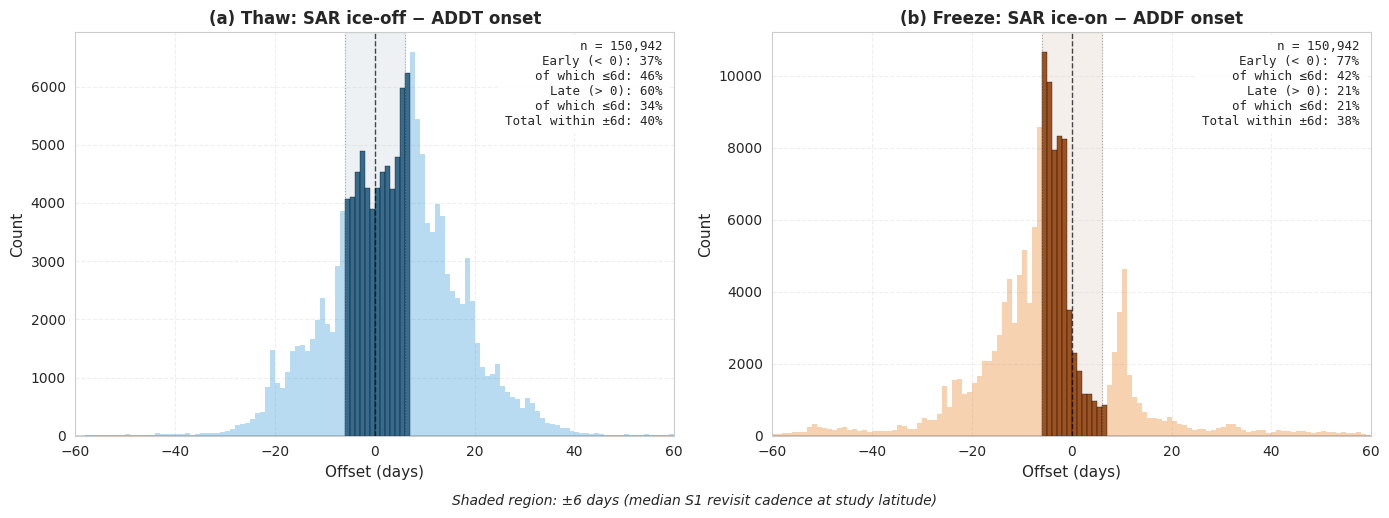

Saved: figures/supplementary/figS15_offset_decomposition.png


In [22]:
# ============================================================
# SUPPLEMENTARY FIGURE S15: Offset Decomposition
# ============================================================
# Decomposes thaw/freeze offsets into fractions within and
# beyond the SAR temporal resolution (median revisit = 6 days).

SAR_REVISIT = 6  # median S1 revisit cadence at study latitude (days)

thaw_mask = addt_analysis['addt_thaw_doy'].notna() & addt_analysis['ice_off_doy'].notna()
freeze_mask = addt_analysis['addf_freeze_doy'].notna() & addt_analysis['ice_on_doy'].notna()
thaw_off = addt_analysis.loc[thaw_mask, 'thaw_offset'].values
freeze_off = addt_analysis.loc[freeze_mask, 'freeze_offset'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, offsets, title, color_main, color_dark in [
    (axes[0], thaw_off, '(a) Thaw: SAR ice-off \u2212 ADDT onset', '#3498db', '#1a5276'),
    (axes[1], freeze_off, '(b) Freeze: SAR ice-on \u2212 ADDF onset', '#e67e22', '#873600')
]:
    bins = np.arange(-61, 62, 1)
    clipped = offsets[(offsets >= -60) & (offsets <= 60)]

    # Full histogram (light)
    ax.hist(clipped, bins=bins, color=color_main, alpha=0.35, edgecolor='none')

    # Highlighted region within +/- SAR_REVISIT
    within = clipped[(clipped >= -SAR_REVISIT) & (clipped <= SAR_REVISIT)]
    ax.hist(within, bins=bins, color=color_dark, alpha=0.8, edgecolor='black', linewidth=0.3)

    # Shaded band and reference lines
    ax.axvspan(-SAR_REVISIT, SAR_REVISIT, color=color_dark, alpha=0.08, zorder=0)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(-SAR_REVISIT, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.axvline(SAR_REVISIT, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

    # Compute statistics
    n_total = len(offsets)
    n_neg = (offsets < 0).sum()
    n_pos = (offsets > 0).sum()
    n_neg_within = ((offsets >= -SAR_REVISIT) & (offsets < 0)).sum()
    n_pos_within = ((offsets > 0) & (offsets <= SAR_REVISIT)).sum()
    n_within = (np.abs(offsets) <= SAR_REVISIT).sum()

    pct_neg = n_neg / n_total * 100
    pct_pos = n_pos / n_total * 100
    pct_within = n_within / n_total * 100
    pct_neg_of_neg = n_neg_within / n_neg * 100 if n_neg > 0 else 0
    pct_pos_of_pos = n_pos_within / n_pos * 100 if n_pos > 0 else 0

    stats_text = (
        f"n = {n_total:,}\n"
        f"Early (< 0): {pct_neg:.0f}%\n"
        f"  of which \u2264{SAR_REVISIT}d: {pct_neg_of_neg:.0f}%\n"
        f"Late (> 0): {pct_pos:.0f}%\n"
        f"  of which \u2264{SAR_REVISIT}d: {pct_pos_of_pos:.0f}%\n"
        f"Total within \u00b1{SAR_REVISIT}d: {pct_within:.0f}%"
    )

    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95))

    ax.set_xlabel('Offset (days)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(-60, 60)

fig.text(0.5, -0.02,
         f'Shaded region: \u00b1{SAR_REVISIT} days (median S1 revisit cadence at study latitude)',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('./figures/supplementary/figS15_offset_decomposition.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS15_offset_decomposition.png")

MANUSCRIPT FIGURE 6: Per-Detection Temporal Uncertainty

  Ice-off: 150,942/150,942 thaw offsets have a per-detection gap
  Ice-on:  150,942/150,942 freeze offsets have a per-detection gap

  Thaw (ice-off):
    Observation gap at detection: median=10d, mean=11.5d, IQR=[6, 12]
    Offsets within 1 gap: 57.4%
    Offsets within 2 gaps (excl. the 1-gap tier): 24.9%
    Offsets within 2 gaps (cumulative <=2): 82.3%
      Pre-S1B failure: gap median=10d, within 1=46.2%, cumulative <=2=76.5%
      Post-S1B failure: gap median=12d, within 1=74.4%, cumulative <=2=91.1%

  Freeze (ice-on):
    Observation gap at detection: median=10d, mean=10.9d, IQR=[6, 12]
    Offsets within 1 gap: 55.4%
    Offsets within 2 gaps (excl. the 1-gap tier): 19.2%
    Offsets within 2 gaps (cumulative <=2): 74.6%
      Pre-S1B failure: gap median=6d, within 1=45.2%, cumulative <=2=65.5%
      Post-S1B failure: gap median=12d, within 1=70.8%, cumulative <=2=88.3%

Data preparation completed in 0.1s


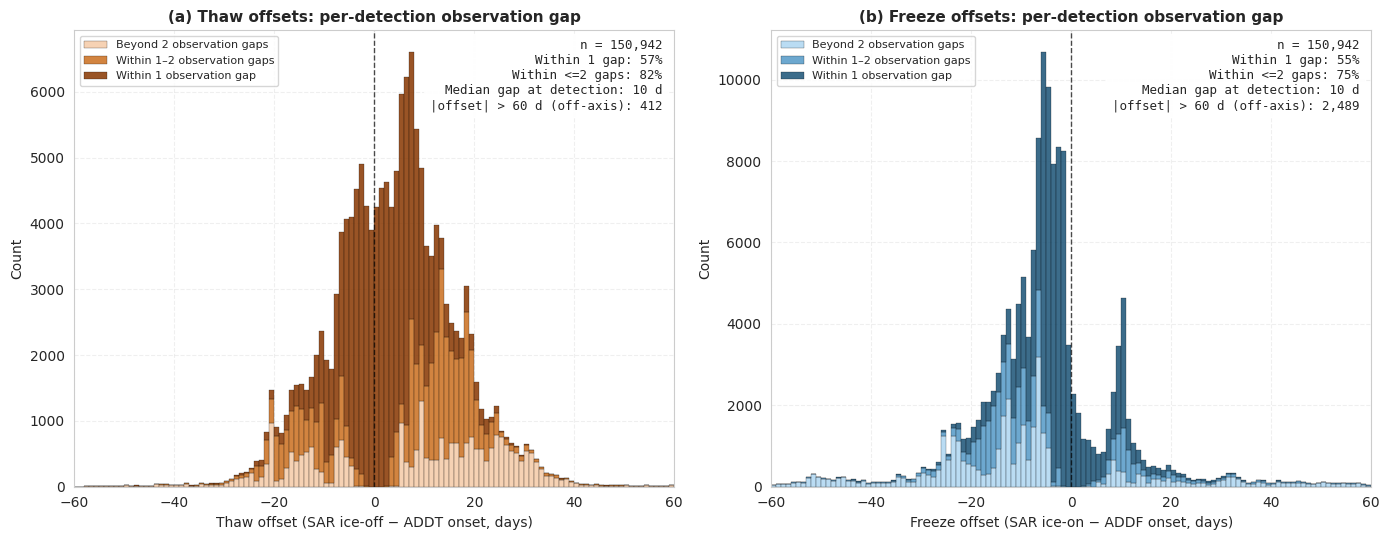


Saved: figures/manuscript/fig06_offset_revisit_analysis.png
  (412 thaw / 2,489 freeze offsets fall outside +/-60 d and are off-axis)


Saved: figure_data/fig06_offset_revisit_analysis.csv (150,942 rows)


In [23]:
# ============================================================
# MANUSCRIPT FIGURE 6: Per-Detection Temporal Uncertainty
# ============================================================
# For each SAR-detected ice-off / ice-on event, the per-detection
# observation gap is the detector's source-to-onset bracket
# (ice_off_width_days / ice_on_width_days): the interval from the last
# confirmed source-state observation to the first confirmed new-state
# observation, i.e. the window within which the true transition lies.
# Offsets vs the ERA5 ADDT/ADDF onset are then expressed in units of that
# per-detection observation gap. If |offset| <= 1 gap, the offset is
# within the SAR temporal-sampling uncertainty of that detection.
#
# NOTE: the transition-based detector stores ice_off_date / ice_on_date as
# the interpolated P(ice)=0.5 crossing (a between-passes timestamp), so the
# gap can no longer be recovered by matching detection dates (or their DOY)
# to the S1 acquisition timeseries. The detector already records the
# bracketing gap per detection as *_width_days; use it directly.

import time
print("=" * 70)
print("MANUSCRIPT FIGURE 6: Per-Detection Temporal Uncertainty")
print("=" * 70)

t0 = time.time()

# ------------------------------------------------------------------
# Step 1: Assemble detections and per-detection observation gaps
# ------------------------------------------------------------------
# The bracket width IS the per-detection observation gap; no merge against
# the S1 acquisition timeseries is needed (see NOTE above).
pheno = addt_analysis[['lake_id', 'year',
                       'ice_off_status', 'ice_on_status',
                       'ice_off_width_days', 'ice_on_width_days',
                       'thaw_offset', 'freeze_offset']].copy()

pheno['ice_off_gap_days'] = pd.to_numeric(pheno['ice_off_width_days'], errors='coerce')
pheno['ice_on_gap_days'] = pd.to_numeric(pheno['ice_on_width_days'], errors='coerce')

# A per-detection gap exists only for EXACT detections; censored detections
# (already open/frozen at a record edge) have no observed bracket. Guard
# against any non-positive width as well.
pheno.loc[pheno['ice_off_status'] != 'exact', 'ice_off_gap_days'] = np.nan
pheno.loc[pheno['ice_on_status'] != 'exact', 'ice_on_gap_days'] = np.nan
pheno.loc[pheno['ice_off_gap_days'] <= 0, 'ice_off_gap_days'] = np.nan
pheno.loc[pheno['ice_on_gap_days'] <= 0, 'ice_on_gap_days'] = np.nan

# Coverage reported among actual offsets (not all phenology rows)
off_offsets = pheno['thaw_offset'].notna()
on_offsets = pheno['freeze_offset'].notna()
n_off = int((off_offsets & pheno['ice_off_gap_days'].notna()).sum())
n_on = int((on_offsets & pheno['ice_on_gap_days'].notna()).sum())
print(f"\n  Ice-off: {n_off:,}/{int(off_offsets.sum()):,} thaw offsets have a per-detection gap")
print(f"  Ice-on:  {n_on:,}/{int(on_offsets.sum()):,} freeze offsets have a per-detection gap")

# ------------------------------------------------------------------
# Step 2: Express offset relative to the per-detection observation gap
# ------------------------------------------------------------------
pheno['thaw_offset_revisits'] = pheno['thaw_offset'] / pheno['ice_off_gap_days']
pheno['freeze_offset_revisits'] = pheno['freeze_offset'] / pheno['ice_on_gap_days']

# Tiers: |offset| within 1 gap, or within 2 gaps (exclusive of the 1-gap tier)
pheno['thaw_within_1_revisit'] = pheno['thaw_offset'].abs() <= pheno['ice_off_gap_days']
pheno['thaw_within_2_revisits'] = (pheno['thaw_offset'].abs() <= 2 * pheno['ice_off_gap_days']) & ~pheno['thaw_within_1_revisit']
pheno['freeze_within_1_revisit'] = pheno['freeze_offset'].abs() <= pheno['ice_on_gap_days']
pheno['freeze_within_2_revisits'] = (pheno['freeze_offset'].abs() <= 2 * pheno['ice_on_gap_days']) & ~pheno['freeze_within_1_revisit']

# Pre/post S1B failure (Dec 2021)
pheno['era'] = np.where(pheno['year'] <= 2021, 'Pre-S1B failure\n(2019–2021)', 'Post-S1B failure\n(2022–2023)')

# Summary statistics
for label, col_gap, col_w1, col_w2, col_offset in [
    ('Thaw (ice-off)', 'ice_off_gap_days', 'thaw_within_1_revisit', 'thaw_within_2_revisits', 'thaw_offset'),
    ('Freeze (ice-on)', 'ice_on_gap_days', 'freeze_within_1_revisit', 'freeze_within_2_revisits', 'freeze_offset'),
]:
    valid = pheno[col_gap].notna() & pheno[col_offset].notna()
    gap_vals = pheno.loc[valid, col_gap]
    w1_vals = pheno.loc[valid, col_w1]
    w2_vals = pheno.loc[valid, col_w2]
    pct_w1 = w1_vals.mean() * 100
    pct_w2 = w2_vals.mean() * 100
    print(f"\n  {label}:")
    print(f"    Observation gap at detection: median={gap_vals.median():.0f}d, "
          f"mean={gap_vals.mean():.1f}d, IQR=[{gap_vals.quantile(0.25):.0f}, {gap_vals.quantile(0.75):.0f}]")
    print(f"    Offsets within 1 gap: {pct_w1:.1f}%")
    print(f"    Offsets within 2 gaps (excl. the 1-gap tier): {pct_w2:.1f}%")
    print(f"    Offsets within 2 gaps (cumulative <=2): {pct_w1 + pct_w2:.1f}%")
    for era_label in ['Pre-S1B failure\n(2019–2021)', 'Post-S1B failure\n(2022–2023)']:
        era_mask = valid & (pheno['era'] == era_label)
        era_gap = pheno.loc[era_mask, col_gap]
        era_w1 = pheno.loc[era_mask, col_w1]
        era_w2 = pheno.loc[era_mask, col_w2]
        era_short = era_label.split('\n')[0]
        print(f"      {era_short}: gap median={era_gap.median():.0f}d, "
              f"within 1={era_w1.mean()*100:.1f}%, cumulative <=2={(era_w1.mean()+era_w2.mean())*100:.1f}%")

elapsed = time.time() - t0
print(f"\nData preparation completed in {elapsed:.1f}s")

# ------------------------------------------------------------------
# Step 3: Figure 6 (panels a & b) — stacked 3-tier histograms
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Color scheme: darkest = within 1, medium = within 2, lightest = beyond 2
c_thaw_w1 = '#873600'
c_thaw_w2 = '#ca6f1e'
c_thaw_beyond = '#f5cba7'
c_freeze_w1 = '#1a5276'
c_freeze_w2 = '#5499c7'
c_freeze_beyond = '#aed6f1'

XLIM = 60
bins = np.arange(-(XLIM + 1), XLIM + 2, 1)
clip = lambda s: s[(s >= -XLIM) & (s <= XLIM)]

# ---- Panel (a): Thaw offset histogram ----
ax = axes[0]
thaw_valid = pheno['thaw_offset'].notna() & pheno['ice_off_gap_days'].notna()
tv = pheno.loc[thaw_valid]
n_clip_thaw = int((tv['thaw_offset'].abs() > XLIM).sum())

beyond_thaw = clip(tv.loc[~tv['thaw_within_1_revisit'] & ~tv['thaw_within_2_revisits'], 'thaw_offset'])
w2_thaw = clip(tv.loc[tv['thaw_within_2_revisits'], 'thaw_offset'])
w1_thaw = clip(tv.loc[tv['thaw_within_1_revisit'], 'thaw_offset'])

ax.hist([beyond_thaw, w2_thaw, w1_thaw], bins=bins, stacked=True,
        color=[c_thaw_beyond, c_thaw_w2, c_thaw_w1],
        edgecolor='black', linewidth=0.2, alpha=0.85,
        label=['Beyond 2 observation gaps', 'Within 1–2 observation gaps', 'Within 1 observation gap'])
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

pct_w1_thaw = tv['thaw_within_1_revisit'].mean() * 100
pct_w12_thaw = (tv['thaw_within_1_revisit'] | tv['thaw_within_2_revisits']).mean() * 100
med_gap_thaw = tv['ice_off_gap_days'].median()
ax.text(0.98, 0.98,
        f'n = {len(tv):,}\n'
        f'Within 1 gap: {pct_w1_thaw:.0f}%\n'
        f'Within <=2 gaps: {pct_w12_thaw:.0f}%\n'
        f'Median gap at detection: {med_gap_thaw:.0f} d\n'
        f'|offset| > {XLIM} d (off-axis): {n_clip_thaw:,}',
        transform=ax.transAxes, fontsize=9, va='top', ha='right',
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95))

ax.set_xlabel('Thaw offset (SAR ice-off − ADDT onset, days)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('(a) Thaw offsets: per-detection observation gap', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-XLIM, XLIM)

# ---- Panel (b): Freeze offset histogram ----
ax = axes[1]
freeze_valid = pheno['freeze_offset'].notna() & pheno['ice_on_gap_days'].notna()
fv = pheno.loc[freeze_valid]
n_clip_freeze = int((fv['freeze_offset'].abs() > XLIM).sum())

beyond_freeze = clip(fv.loc[~fv['freeze_within_1_revisit'] & ~fv['freeze_within_2_revisits'], 'freeze_offset'])
w2_freeze = clip(fv.loc[fv['freeze_within_2_revisits'], 'freeze_offset'])
w1_freeze = clip(fv.loc[fv['freeze_within_1_revisit'], 'freeze_offset'])

ax.hist([beyond_freeze, w2_freeze, w1_freeze], bins=bins, stacked=True,
        color=[c_freeze_beyond, c_freeze_w2, c_freeze_w1],
        edgecolor='black', linewidth=0.2, alpha=0.85,
        label=['Beyond 2 observation gaps', 'Within 1–2 observation gaps', 'Within 1 observation gap'])
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

pct_w1_freeze = fv['freeze_within_1_revisit'].mean() * 100
pct_w12_freeze = (fv['freeze_within_1_revisit'] | fv['freeze_within_2_revisits']).mean() * 100
med_gap_freeze = fv['ice_on_gap_days'].median()
ax.text(0.98, 0.98,
        f'n = {len(fv):,}\n'
        f'Within 1 gap: {pct_w1_freeze:.0f}%\n'
        f'Within <=2 gaps: {pct_w12_freeze:.0f}%\n'
        f'Median gap at detection: {med_gap_freeze:.0f} d\n'
        f'|offset| > {XLIM} d (off-axis): {n_clip_freeze:,}',
        transform=ax.transAxes, fontsize=9, va='top', ha='right',
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95))

ax.set_xlabel('Freeze offset (SAR ice-on − ADDF onset, days)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('(b) Freeze offsets: per-detection observation gap', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-XLIM, XLIM)

plt.tight_layout()
plt.savefig('./figures/manuscript/fig06_offset_revisit_analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: figures/manuscript/fig06_offset_revisit_analysis.png")
print(f"  ({n_clip_thaw:,} thaw / {n_clip_freeze:,} freeze offsets fall outside +/-{XLIM} d and are off-axis)")

# ------------------------------------------------------------------
# Step 4: Export figure data
# ------------------------------------------------------------------
# thaw_gap_valid / freeze_gap_valid distinguish "evaluated and beyond" from
# "not evaluated" (censored or no gap): the within-tier booleans are False in
# both cases, so downstream users should filter on the *_gap_valid flags.
export = pheno[['lake_id', 'year', 'thaw_offset', 'freeze_offset',
                'ice_off_gap_days', 'ice_on_gap_days',
                'thaw_within_1_revisit', 'thaw_within_2_revisits',
                'freeze_within_1_revisit', 'freeze_within_2_revisits']].copy()
export['thaw_gap_valid'] = pheno['thaw_offset'].notna() & pheno['ice_off_gap_days'].notna()
export['freeze_gap_valid'] = pheno['freeze_offset'].notna() & pheno['ice_on_gap_days'].notna()
export.to_csv('figure_data/fig06_offset_revisit_analysis.csv', index=False)
print(f"Saved: figure_data/fig06_offset_revisit_analysis.csv ({len(export):,} rows)")


## Outlier Investigation\n\nInvestigate potential outliers including Teshekpuk Lake (largest lake in the dataset).

In [24]:
# Load ERA5 temperature data and compute mean spring temperature per lake-year
from google.cloud import storage
import warnings
warnings.filterwarnings('ignore')

print("Loading ERA5 temperature data...")

BUCKET_NAME = 'wustl-eeps-geospatial'
EXPORT_PREFIX = 'thermokarst_lakes/exports'
YEARS = [2019, 2020, 2021, 2022, 2023]

# Load ERA5 data for all years
era5_chunks = []
for year in YEARS:
    for chunk_id in range(21):
        try:
            chunk_path = f'gs://{BUCKET_NAME}/{EXPORT_PREFIX}/{year}/chunk_{chunk_id:02d}/era5_data.csv'
            chunk = pd.read_csv(chunk_path)
            chunk['year'] = year
            era5_chunks.append(chunk)
        except FileNotFoundError:
            continue

if len(era5_chunks) == 0:
    raise FileNotFoundError('No ERA5 chunk files could be loaded')
expected_chunks = len(YEARS) * 21
if len(era5_chunks) < expected_chunks:
    print(f'WARNING: Loaded {len(era5_chunks)}/{expected_chunks} ERA5 chunks')
era5 = pd.concat(era5_chunks, ignore_index=True)
era5 = era5.rename(columns={'id': 'lake_id'})
era5['era5_date'] = pd.to_datetime(era5['era5_date'])
era5['month'] = era5['era5_date'].dt.month

print(f"ERA5 data loaded: {len(era5):,} observations")

# Compute mean spring temperature (April-June) per lake-year
spring_era5 = era5[era5['month'].isin([4, 5, 6])]
mean_spring_temp = spring_era5.groupby(['lake_id', 'year'])['temp_c'].mean().reset_index()
mean_spring_temp = mean_spring_temp.rename(columns={'temp_c': 'mean_spring_temp'})

print(f"Mean spring temp computed for {len(mean_spring_temp):,} lake-years")
print(f"Temperature range: {mean_spring_temp['mean_spring_temp'].min():.1f}°C to {mean_spring_temp['mean_spring_temp'].max():.1f}°C")

Loading ERA5 temperature data...


ERA5 data loaded: 56,803,208 observations


Mean spring temp computed for 155,540 lake-years
Temperature range: -6.3°C to 1.6°C


In [25]:
# Merge phenology data with spring temperature
regression_data = complete.merge(mean_spring_temp, on=['lake_id', 'year'], how='inner')

# Create log(area) variable
regression_data['log_area'] = np.log10(regression_data['area_km2'])

# Check for required columns and drop rows with missing values
required_cols = ['ice_off_doy', 'ice_on_doy', 'ice_free_days', 
                 'mean_spring_temp', 'log_area', 'sdi', 'circularity', 'convexity']

# Check which columns exist
missing_cols = [c for c in required_cols if c not in regression_data.columns]
if missing_cols:
    print(f"Warning: Missing columns: {missing_cols}")
    # Try alternative column names
    if 'shoreline_dev' in regression_data.columns and 'sdi' in missing_cols:
        regression_data['sdi'] = regression_data['shoreline_dev']
        missing_cols.remove('sdi')

available_cols = [c for c in required_cols if c in regression_data.columns]
reg_df = regression_data[['lake_id', 'year', 'centroid_lat', 'centroid_lon'] + available_cols].dropna()

print(f"Regression dataset: {len(reg_df):,} lake-year observations")
print(f"Variables available: {available_cols}")
print(f"\nDescriptive statistics:")
print(reg_df[available_cols].describe().round(2))

Regression dataset: 150,942 lake-year observations
Variables available: ['ice_off_doy', 'ice_on_doy', 'ice_free_days', 'mean_spring_temp', 'log_area', 'sdi', 'circularity', 'convexity']

Descriptive statistics:
       ice_off_doy  ice_on_doy  ice_free_days  mean_spring_temp   log_area  \
count    150942.00   150942.00      150942.00         150942.00  150942.00   
mean        159.02      272.83         113.81             -3.29      -1.04   
std          12.86       16.63          25.50              1.19       0.55   
min           7.00       30.00           3.00             -6.24      -1.70   
25%         152.00      265.00         100.00             -4.15      -1.48   
50%         160.00      272.00         112.00             -3.42      -1.18   
75%         167.00      281.00         126.00             -2.48      -0.72   
max         303.00      366.00         331.00              1.65       2.93   

             sdi  circularity  convexity  
count  150942.00    150942.00  150942.00  


In [26]:
# Multiple regression analysis with statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("="*70)
print("MULTIPLE REGRESSION ANALYSIS")
print("="*70)

# Define response variables and predictors
response_vars = ['ice_off_doy', 'ice_on_doy', 'ice_free_days']
morph_predictors = ['log_area', 'sdi', 'circularity', 'convexity']

# Filter to available predictors
morph_predictors = [p for p in morph_predictors if p in reg_df.columns]

results_summary = {}

for response in response_vars:
    print(f"\n{'='*70}")
    print(f"Response Variable: {response.upper()}")
    print("="*70)
    
    y = reg_df[response]
    
    # Model 1: Temperature only
    X_temp = sm.add_constant(reg_df[['mean_spring_temp']])
    model_temp = sm.OLS(y, X_temp).fit()
    r2_temp = model_temp.rsquared
    
    # Model 2: Temperature + Morphometry
    X_full = sm.add_constant(reg_df[['mean_spring_temp'] + morph_predictors])
    model_full = sm.OLS(y, X_full).fit()
    r2_full = model_full.rsquared
    
    # Store results
    results_summary[response] = {
        'r2_temp_only': r2_temp,
        'r2_full': r2_full,
        'r2_added_by_morph': r2_full - r2_temp,
        'model': model_full
    }
    
    print(f"\nR² (temperature only):      {r2_temp:.4f} ({r2_temp*100:.1f}%)")
    print(f"R² (temp + morphometry):    {r2_full:.4f} ({r2_full*100:.1f}%)")
    print(f"R² added by morphometry:    {r2_full - r2_temp:.4f} ({(r2_full - r2_temp)*100:.1f}%)")
    
    print(f"\n--- Coefficient Table ---")
    print(model_full.summary().tables[1])

MULTIPLE REGRESSION ANALYSIS

Response Variable: ICE_OFF_DOY

R² (temperature only):      0.1522 (15.2%)
R² (temp + morphometry):    0.1676 (16.8%)
R² added by morphometry:    0.0154 (1.5%)

--- Coefficient Table ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              125.3349      0.627    200.034      0.000     124.107     126.563
mean_spring_temp    -4.0858      0.026   -160.044      0.000      -4.136      -4.036
log_area             0.1603      0.064      2.506      0.012       0.035       0.286
sdi                  3.7645      0.121     31.157      0.000       3.528       4.001
circularity         -6.7955      0.493    -13.778      0.000      -7.762      -5.829
convexity           19.1952      0.547     35.097      0.000      18.123      20.267

Response Variable: ICE_ON_DOY

R² (temperature only):      0.1354 (13.5%)
R² (temp + morphometry):    

In [27]:
# Effect size interpretation and significance summary
print("="*70)
print("EFFECT SIZE INTERPRETATION")
print("="*70)

for response, res in results_summary.items():
    model = res['model']
    params = model.params
    pvals = model.pvalues
    conf_int = model.conf_int()
    
    print(f"\n--- {response.upper()} ---")
    
    for predictor in ['mean_spring_temp'] + morph_predictors:
        if predictor in params.index:
            coef = params[predictor]
            pval = pvals[predictor]
            ci_low, ci_high = conf_int.loc[predictor]
            
            sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
            
            # Interpretation
            if predictor == 'mean_spring_temp':
                interp = f"1°C warmer spring → {coef:+.2f} days"
            elif predictor == 'log_area':
                interp = f"10x larger lake → {coef:+.2f} days"
            elif predictor == 'sdi':
                interp = f"1 unit SDI increase → {coef:+.2f} days"
            elif predictor == 'circularity':
                interp = f"0.1 more circular → {coef*0.1:+.2f} days"
            elif predictor == 'convexity':
                interp = f"0.1 more convex → {coef*0.1:+.2f} days"
            else:
                interp = f"1 unit increase → {coef:+.2f} days"
            
            print(f"  {predictor:18s}: coef={coef:+8.3f}, p={pval:.2e} {sig:3s}  | {interp}")

EFFECT SIZE INTERPRETATION

--- ICE_OFF_DOY ---
  mean_spring_temp  : coef=  -4.086, p=0.00e+00 ***  | 1°C warmer spring → -4.09 days
  log_area          : coef=  +0.160, p=1.22e-02 *    | 10x larger lake → +0.16 days
  sdi               : coef=  +3.765, p=1.96e-212 ***  | 1 unit SDI increase → +3.76 days
  circularity       : coef=  -6.796, p=3.69e-43 ***  | 0.1 more circular → -0.68 days
  convexity         : coef= +19.195, p=9.12e-269 ***  | 0.1 more convex → +1.92 days

--- ICE_ON_DOY ---
  mean_spring_temp  : coef=  +4.966, p=0.00e+00 ***  | 1°C warmer spring → +4.97 days
  log_area          : coef=  +3.605, p=0.00e+00 ***  | 10x larger lake → +3.60 days
  sdi               : coef=  -5.528, p=8.48e-271 ***  | 1 unit SDI increase → -5.53 days
  circularity       : coef=  +8.386, p=3.81e-39 ***  | 0.1 more circular → +0.84 days
  convexity         : coef= -20.094, p=1.25e-175 ***  | 0.1 more convex → -2.01 days

--- ICE_FREE_DAYS ---
  mean_spring_temp  : coef=  +9.049, p=0.00e+00 *

In [28]:
# Spatial autocorrelation check using Moran's I
print("\n" + "="*70)
print("SPATIAL AUTOCORRELATION CHECK (Moran's I)")
print("="*70)

try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    
    # Use lake centroids for spatial weights
    # Aggregate residuals by lake (mean across years)
    for response, res in results_summary.items():
        model = res['model']
        
        # Get residuals and add to dataframe
        reg_df_temp = reg_df.copy()
        reg_df_temp['residuals'] = model.resid
        
        # Aggregate by lake (mean residual)
        lake_resid = reg_df_temp.groupby('lake_id').agg({
            'residuals': 'mean',
            'centroid_lat': 'first',
            'centroid_lon': 'first'
        }).dropna().reset_index()
        
        if len(lake_resid) < 10:
            print(f"\n{response}: Too few lakes for spatial analysis")
            continue
        
        # Create spatial weights matrix (KNN with k=8)
        coords = lake_resid[['centroid_lon', 'centroid_lat']].values
        w = KNN.from_array(coords, k=8)
        w.transform = 'R'  # Row-standardize
        
        # Calculate Moran's I
        moran = Moran(lake_resid['residuals'].values, w)
        
        print(f"\n{response}:")
        print(f"  Moran's I = {moran.I:.4f}")
        print(f"  Expected I = {moran.EI:.4f}")
        print(f"  p-value = {moran.p_sim:.4f}")
        
        if abs(moran.I) < 0.1:
            print(f"  → Low spatial autocorrelation - temperature adequately captures spatial patterns")
        elif abs(moran.I) < 0.3:
            print(f"  → Moderate spatial autocorrelation - consider spatial regression")
        else:
            print(f"  → High spatial autocorrelation - spatial regression recommended")
        
        res['morans_i'] = moran.I
        res['morans_p'] = moran.p_sim

except ImportError as e:
    print(f"\nNote: libpysal/esda not available for Moran's I calculation")
    print(f"Install with: pip install libpysal esda")
    print(f"Error: {e}")
except Exception as e:
    print(f"\nError calculating Moran's I: {e}")


SPATIAL AUTOCORRELATION CHECK (Moran's I)



ice_off_doy:
  Moran's I = 0.4394
  Expected I = -0.0000
  p-value = 0.0010
  → High spatial autocorrelation - spatial regression recommended



ice_on_doy:
  Moran's I = 0.3477
  Expected I = -0.0000
  p-value = 0.0010
  → High spatial autocorrelation - spatial regression recommended



ice_free_days:
  Moran's I = 0.4509
  Expected I = -0.0000
  p-value = 0.0010
  → High spatial autocorrelation - spatial regression recommended


In [29]:
# Summary of key findings
print("\n" + "="*70)
print("TEMPERATURE-CONTROLLED REGRESSION: KEY FINDINGS")
print("="*70)

for response, res in results_summary.items():
    model = res['model']
    r2_temp = res['r2_temp_only']
    r2_full = res['r2_full']
    r2_added = res['r2_added_by_morph']
    
    print(f"\n--- {response.replace('_', ' ').upper()} ---")
    print(f"  • Temperature explains {r2_temp*100:.1f}% of variance")
    print(f"  • Morphometry adds {r2_added*100:.1f}% after controlling for temperature")
    print(f"  • Total R² = {r2_full*100:.1f}%")
    
    # Significant morphometry effects
    sig_effects = []
    for pred in morph_predictors:
        if pred in model.pvalues.index and model.pvalues[pred] < 0.05:
            coef = model.params[pred]
            pval = model.pvalues[pred]
            sig_effects.append(f"{pred} (β={coef:+.2f}, p={pval:.2e})")
    
    if sig_effects:
        print(f"  • Significant morphometry effects: {', '.join(sig_effects)}")
    else:
        print(f"  • No morphometry variables significant at p<0.05")
    
    if 'morans_i' in res:
        print(f"  • Residual Moran's I = {res['morans_i']:.3f} (p={res['morans_p']:.3f})")

print("\n" + "="*70)
print("INTERPRETATION NOTES")
print("="*70)
print("""
1. Temperature is the dominant control on ice phenology timing
2. Morphometry effects are small but may be statistically significant given large N
3. If Moran's I is low, spatial patterns are well-captured by temperature
4. Effect sizes show practical significance (days change per unit predictor)
""")


TEMPERATURE-CONTROLLED REGRESSION: KEY FINDINGS

--- ICE OFF DOY ---
  • Temperature explains 15.2% of variance
  • Morphometry adds 1.5% after controlling for temperature
  • Total R² = 16.8%
  • Significant morphometry effects: log_area (β=+0.16, p=1.22e-02), sdi (β=+3.76, p=1.96e-212), circularity (β=-6.80, p=3.69e-43), convexity (β=+19.20, p=9.12e-269)
  • Residual Moran's I = 0.439 (p=0.001)

--- ICE ON DOY ---
  • Temperature explains 13.5% of variance
  • Morphometry adds 2.5% after controlling for temperature
  • Total R² = 16.1%
  • Significant morphometry effects: log_area (β=+3.60, p=0.00e+00), sdi (β=-5.53, p=8.48e-271), circularity (β=+8.39, p=3.81e-39), convexity (β=-20.09, p=1.25e-175)
  • Residual Moran's I = 0.348 (p=0.001)

--- ICE FREE DAYS ---
  • Temperature explains 19.1% of variance
  • Morphometry adds 2.1% after controlling for temperature
  • Total R² = 21.2%
  • Significant morphometry effects: log_area (β=+3.43, p=8.23e-170), sdi (β=-9.29, p=0.00e+00), circ

## Part 8: Spatial Regression Analysis

The OLS regression shows high residual spatial autocorrelation (Moran's I ≈ 0.44), which can:
- Bias coefficient estimates
- Inflate significance (underestimate standard errors)

We address this using spatial econometric models to test whether morphometry effects (especially SDI) remain significant after proper spatial correction.

In [30]:
# Aggregate to lake-level means for spatial regression
# Spatial models assume one observation per spatial unit

lake_spatial = reg_df.groupby('lake_id').agg({
    'ice_off_doy': 'mean',
    'ice_on_doy': 'mean',
    'ice_free_days': 'mean',
    'mean_spring_temp': 'mean',
    'log_area': 'first',
    'sdi': 'first',
    'circularity': 'first',
    'convexity': 'first',
    'centroid_lat': 'first',
    'centroid_lon': 'first'
}).reset_index().dropna()

print(f"Aggregated to {len(lake_spatial):,} lakes (mean across years)")
print(f"\nVariable ranges:")
for var in ['ice_off_doy', 'ice_on_doy', 'ice_free_days', 'mean_spring_temp']:
    print(f"  {var}: {lake_spatial[var].min():.1f} to {lake_spatial[var].max():.1f}")

Aggregated to 30,725 lakes (mean across years)

Variable ranges:
  ice_off_doy: 18.0 to 298.5
  ice_on_doy: 34.0 to 362.0
  ice_free_days: 3.0 to 318.0
  mean_spring_temp: -6.1 to -0.5


In [31]:
# Build spatial weights matrix (KNN k=8, consistent with Moran's I calculation)
from libpysal.weights import KNN

print("Building spatial weights matrix...")
coords = lake_spatial[['centroid_lon', 'centroid_lat']].values
w = KNN.from_array(coords, k=8)
w.transform = 'R'  # Row-standardize

print(f"Spatial weights matrix: {w.n} observations")
print(f"Mean neighbors: {w.mean_neighbors:.1f}")
print(f"Min/Max neighbors: {w.min_neighbors}/{w.max_neighbors}")

Building spatial weights matrix...


Spatial weights matrix: 30725 observations
Mean neighbors: 8.0
Min/Max neighbors: 8/8


In [32]:
# LM Diagnostic Tests - determine whether Spatial Error or Spatial Lag is more appropriate
import spreg

print("="*70)
print("LAGRANGE MULTIPLIER DIAGNOSTIC TESTS")
print("="*70)
print("\nThese tests guide spatial model selection:")
print("  LM-Error: Tests for spatial error autocorrelation")
print("  LM-Lag: Tests for spatial lag dependence")
print("  Robust versions: Account for presence of the other type")
print()

# Prepare data for spreg
y_vars = ['ice_off_doy', 'ice_on_doy', 'ice_free_days']
x_vars = ['mean_spring_temp', 'log_area', 'sdi', 'circularity', 'convexity']

lm_results = {}

for y_var in y_vars:
    print(f"\n--- {y_var.upper()} ---")
    
    y = lake_spatial[y_var].values.reshape(-1, 1)
    X = lake_spatial[x_vars].values
    
    # Run OLS with spatial diagnostics
    ols = spreg.OLS(y, X, w=w, name_y=y_var, name_x=x_vars, 
                    spat_diag=True, moran=True)
    
    # Extract LM test results
    print(f"  LM-Error:        stat={ols.lm_error[0]:.2f}, p={ols.lm_error[1]:.4f}")
    print(f"  LM-Lag:          stat={ols.lm_lag[0]:.2f}, p={ols.lm_lag[1]:.4f}")
    print(f"  Robust LM-Error: stat={ols.rlm_error[0]:.2f}, p={ols.rlm_error[1]:.4f}")
    print(f"  Robust LM-Lag:   stat={ols.rlm_lag[0]:.2f}, p={ols.rlm_lag[1]:.4f}")
    
    # Decision rule
    if ols.rlm_error[0] > ols.rlm_lag[0]:
        rec = "Spatial Error Model"
    else:
        rec = "Spatial Lag Model"
    print(f"  → Recommendation: {rec}")
    
    lm_results[y_var] = {
        'ols': ols,
        'lm_error': ols.lm_error,
        'lm_lag': ols.lm_lag,
        'rlm_error': ols.rlm_error,
        'rlm_lag': ols.rlm_lag,
        'recommendation': rec
    }

LAGRANGE MULTIPLIER DIAGNOSTIC TESTS

These tests guide spatial model selection:
  LM-Error: Tests for spatial error autocorrelation
  LM-Lag: Tests for spatial lag dependence
  Robust versions: Account for presence of the other type


--- ICE_OFF_DOY ---


  LM-Error:        stat=16147.06, p=0.0000
  LM-Lag:          stat=16070.90, p=0.0000
  Robust LM-Error: stat=237.91, p=0.0000
  Robust LM-Lag:   stat=161.75, p=0.0000
  → Recommendation: Spatial Error Model

--- ICE_ON_DOY ---
  LM-Error:        stat=13308.06, p=0.0000
  LM-Lag:          stat=12723.89, p=0.0000
  Robust LM-Error: stat=587.32, p=0.0000
  Robust LM-Lag:   stat=3.14, p=0.0764
  → Recommendation: Spatial Error Model

--- ICE_FREE_DAYS ---


  LM-Error:        stat=20120.37, p=0.0000
  LM-Lag:          stat=19309.54, p=0.0000
  Robust LM-Error: stat=830.43, p=0.0000
  Robust LM-Lag:   stat=19.60, p=0.0000
  → Recommendation: Spatial Error Model


In [33]:
# Fit Spatial Error Models (GM estimator - fast for large N)
from spreg import GM_Error_Het

print("="*70)
print("SPATIAL ERROR MODEL (GM Estimator)")
print("="*70)
print("\nModel: y = Xβ + u, where u = λWu + ε")
print("Interpretation: Spatially correlated unobserved factors affect y")
print()

sem_results = {}

for y_var in y_vars:
    print(f"\n--- {y_var.upper()} ---")
    
    y = lake_spatial[y_var].values.reshape(-1, 1)
    X = lake_spatial[x_vars].values
    
    # Fit Spatial Error Model with heteroskedasticity-robust SEs
    sem = GM_Error_Het(y, X, w=w, name_y=y_var, name_x=x_vars)
    
    # Extract results
    print(f"\n  λ (spatial error): {sem.betas[-1][0]:.4f}")
    print(f"\n  Coefficients:")
    print(f"  {'Variable':<20} {'Coef':>10} {'Std Err':>10} {'z':>10} {'p-value':>10}")
    print(f"  {'-'*60}")
    
    # Constant
    print(f"  {'CONSTANT':<20} {sem.betas[0][0]:>10.4f} {sem.std_err[0]:>10.4f} "
          f"{sem.z_stat[0][0]:>10.4f} {sem.z_stat[0][1]:>10.4f}")
    
    # Variables
    for i, var in enumerate(x_vars):
        coef = sem.betas[i+1][0]
        se = sem.std_err[i+1]
        z = sem.z_stat[i+1][0]
        p = sem.z_stat[i+1][1]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {var:<20} {coef:>10.4f} {se:>10.4f} {z:>10.4f} {p:>10.4f} {sig}")
    
    sem_results[y_var] = sem

print("\n" + "="*70)

SPATIAL ERROR MODEL (GM Estimator)

Model: y = Xβ + u, where u = λWu + ε
Interpretation: Spatially correlated unobserved factors affect y


--- ICE_OFF_DOY ---



  λ (spatial error): 0.6415

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               118.8939     1.1919    99.7515     0.0000
  mean_spring_temp        -8.4714     0.2065   -41.0158     0.0000 ***
  log_area                -0.0516     0.0954    -0.5408     0.5887 
  sdi                      2.5741     0.2040    12.6200     0.0000 ***
  circularity             -4.4582     0.7772    -5.7361     0.0000 ***
  convexity               10.8057     0.8885    12.1615     0.0000 ***

--- ICE_ON_DOY ---



  λ (spatial error): 0.5858

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               321.2367     1.8758   171.2514     0.0000
  mean_spring_temp         8.9985     0.2873    31.3228     0.0000 ***
  log_area                 3.5192     0.1267    27.7779     0.0000 ***
  sdi                     -4.2571     0.3092   -13.7672     0.0000 ***
  circularity              5.6904     1.1348     5.0145     0.0000 ***
  convexity              -11.0502     1.3480    -8.1972     0.0000 ***

--- ICE_FREE_DAYS ---



  λ (spatial error): 0.6596

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               201.6364     2.6842    75.1202     0.0000
  mean_spring_temp        17.3692     0.4592    37.8276     0.0000 ***
  log_area                 3.5720     0.1869    19.1087     0.0000 ***
  sdi                     -6.7506     0.4429   -15.2430     0.0000 ***
  circularity             10.2155     1.6338     6.2527     0.0000 ***
  convexity              -21.4811     1.9101   -11.2458     0.0000 ***



In [34]:
# Compare residual Moran's I: OLS vs SEM (filtered residuals)
# The SEM composite residuals (u) still contain spatial structure by construction
# We need the FILTERED residuals: ε = u - λWu = (I - λW)u

from esda.moran import Moran
import scipy.sparse as sp

print("="*70)
print("RESIDUAL MORAN'S I: OLS vs SEM FILTERED RESIDUALS")
print("="*70)
print("\nFiltered residuals ε = u - λWu remove the spatial error component")
print()

moran_comparison = []

for y_var in y_vars:
    # OLS residuals
    ols = lm_results[y_var]['ols']
    ols_resid = ols.u.flatten()
    
    # SEM composite residuals and lambda
    sem = sem_results[y_var]
    u = sem.u.flatten()  # Composite error: u = λWu + ε
    lambda_val = sem.betas[-1][0]  # Spatial error parameter
    
    # Compute Wu (spatial lag of residuals)
    # w.sparse is the sparse weights matrix
    W_sparse = w.sparse
    Wu = W_sparse @ u
    
    # Filtered residuals: ε = u - λWu
    epsilon = u - lambda_val * Wu
    
    # Compute Moran's I for both
    moran_ols = Moran(ols_resid, w)
    moran_filtered = Moran(epsilon, w)
    
    # Calculate reduction
    reduction = (moran_ols.I - moran_filtered.I) / moran_ols.I * 100
    
    moran_comparison.append({
        'response': y_var,
        'ols_I': moran_ols.I,
        'ols_p': moran_ols.p_sim,
        'sem_I': moran_filtered.I,
        'sem_p': moran_filtered.p_sim,
        'lambda': lambda_val,
        'reduction': reduction
    })

# Print comparison table
print(f"{'Response':<15} {'OLS Moran I':>11} {'p':>6} {'SEM ε Moran I':>13} {'p':>6} {'λ':>6} {'Reduction':>10}")
print("-"*70)

for row in moran_comparison:
    ols_sig = "***" if row['ols_p'] < 0.001 else ""
    sem_sig = "***" if row['sem_p'] < 0.001 else ("**" if row['sem_p'] < 0.01 else ("*" if row['sem_p'] < 0.05 else "ns"))
    print(f"{row['response']:<15} {row['ols_I']:>11.4f} {row['ols_p']:>5.3f}{ols_sig:1} "
          f"{row['sem_I']:>13.4f} {row['sem_p']:>5.3f} {sem_sig:3} {row['lambda']:>5.3f} {row['reduction']:>9.1f}%")

print("\n" + "-"*70)
print("INTERPRETATION:")
avg_reduction = sum(r['reduction'] for r in moran_comparison) / len(moran_comparison)
print(f"  • Average reduction in Moran's I: {avg_reduction:.1f}%")

if all(r['sem_p'] > 0.05 for r in moran_comparison):
    print("  • SEM filtered residuals show NO significant spatial autocorrelation")
    print("  • ✓ Spatial Error Model successfully accounts for spatial structure")
elif avg_reduction > 50:
    print("  • Substantial reduction in spatial autocorrelation")
    print("  • ✓ Spatial Error Model captures most of the spatial structure")
else:
    print("  • Moderate reduction - some residual spatial autocorrelation remains")
    print("  • Consider spatial Durbin model or additional regional covariates")

RESIDUAL MORAN'S I: OLS vs SEM FILTERED RESIDUALS

Filtered residuals ε = u - λWu remove the spatial error component



Response        OLS Moran I      p SEM ε Moran I      p      λ  Reduction
----------------------------------------------------------------------
ice_off_doy          0.3459 0.001        -0.0201 0.001 **  0.642     105.8%
ice_on_doy           0.3140 0.001        -0.0044 0.056 ns  0.586     101.4%
ice_free_days        0.3861 0.001        -0.0119 0.001 **  0.660     103.1%

----------------------------------------------------------------------
INTERPRETATION:
  • Average reduction in Moran's I: 103.4%
  • Substantial reduction in spatial autocorrelation
  • ✓ Spatial Error Model captures most of the spatial structure


In [35]:
# Fit Spatial Lag Models (GM estimator)
from spreg import GM_Lag

print("="*70)
print("SPATIAL LAG MODEL (GM Estimator)")
print("="*70)
print("\nModel: y = ρWy + Xβ + ε")
print("Interpretation: Neighboring lakes directly influence each other's ice timing")
print()

slm_results = {}

for y_var in y_vars:
    print(f"\n--- {y_var.upper()} ---")
    
    y = lake_spatial[y_var].values.reshape(-1, 1)
    X = lake_spatial[x_vars].values
    
    # Fit Spatial Lag Model
    slm = GM_Lag(y, X, w=w, name_y=y_var, name_x=x_vars)
    
    # Extract results - rho is second to last coefficient in betas
    rho = slm.betas[-1][0]
    print(f"\n  ρ (spatial lag): {rho:.4f}")
    print(f"\n  Coefficients:")
    print(f"  {'Variable':<20} {'Coef':>10} {'Std Err':>10} {'z':>10} {'p-value':>10}")
    print(f"  {'-'*60}")
    
    # Constant
    print(f"  {'CONSTANT':<20} {slm.betas[0][0]:>10.4f} {slm.std_err[0]:>10.4f} "
          f"{slm.z_stat[0][0]:>10.4f} {slm.z_stat[0][1]:>10.4f}")
    
    # Variables (note: slm has rho as last coefficient)
    for i, var in enumerate(x_vars):
        coef = slm.betas[i+1][0]
        se = slm.std_err[i+1]
        z = slm.z_stat[i+1][0]
        p = slm.z_stat[i+1][1]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {var:<20} {coef:>10.4f} {se:>10.4f} {z:>10.4f} {p:>10.4f} {sig}")
    
    slm_results[y_var] = slm

print("\n" + "="*70)

SPATIAL LAG MODEL (GM Estimator)

Model: y = ρWy + Xβ + ε
Interpretation: Neighboring lakes directly influence each other's ice timing


--- ICE_OFF_DOY ---

  ρ (spatial lag): 0.8000

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT                14.5569     4.2114     3.4565     0.0005
  mean_spring_temp        -1.7175     0.2978    -5.7673     0.0000 ***
  log_area                 0.0443     0.0929     0.4773     0.6331 
  sdi                      2.4668     0.1727    14.2840     0.0000 ***
  circularity             -3.4479     0.7075    -4.8735     0.0000 ***
  convexity                9.9352     0.7862    12.6370     0.0000 ***

--- ICE_ON_DOY ---

  ρ (spatial lag): 0.2943

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               235.7597    13.7848    17.1028 


  ρ (spatial lag): 0.5524

  Coefficients:
  Variable                   Coef    Std Err          z    p-value
  ------------------------------------------------------------
  CONSTANT               110.5416     7.3011    15.1404     0.0000
  mean_spring_temp         7.8846     0.6933    11.3733     0.0000 ***
  log_area                 3.2140     0.1943    16.5396     0.0000 ***
  sdi                     -7.2357     0.3707   -19.5168     0.0000 ***
  circularity              7.2610     1.4945     4.8586     0.0000 ***
  convexity              -23.4276     1.6860   -13.8950     0.0000 ***



In [36]:
# Coefficient Comparison Table: OLS vs SEM vs SLM
print("="*70)
print("COEFFICIENT COMPARISON: OLS vs SPATIAL MODELS")
print("="*70)

for y_var in y_vars:
    print(f"\n{'='*70}")
    print(f"Response: {y_var.upper()}")
    print("="*70)
    
    ols = lm_results[y_var]['ols']
    sem = sem_results[y_var]
    slm = slm_results[y_var]
    
    # Build comparison table
    print(f"\n{'Variable':<18} {'OLS β':>10} {'OLS p':>8} {'SEM β':>10} {'SEM p':>8} {'SLM β':>10} {'SLM p':>8}")
    print("-"*74)
    
    for i, var in enumerate(x_vars):
        # OLS
        ols_coef = ols.betas[i+1][0]
        ols_p = ols.t_stat[i+1][1]
        
        # SEM
        sem_coef = sem.betas[i+1][0]
        sem_p = sem.z_stat[i+1][1]
        
        # SLM
        slm_coef = slm.betas[i+1][0]
        slm_p = slm.z_stat[i+1][1]
        
        # Format p-values
        def fmt_p(p):
            if p < 0.001:
                return "<0.001"
            else:
                return f"{p:.3f}"
        
        print(f"{var:<18} {ols_coef:>10.3f} {fmt_p(ols_p):>8} {sem_coef:>10.3f} {fmt_p(sem_p):>8} {slm_coef:>10.3f} {fmt_p(slm_p):>8}")
    
    # Spatial parameters
    print("-"*74)
    lambda_val = sem.betas[-1][0]
    rho_val = slm.betas[-1][0]
    print(f"{'λ (error):':<18} {'--':>10} {'--':>8} {lambda_val:>10.3f} {'':>8} {'--':>10} {'--':>8}")
    print(f"{'ρ (lag):':<18} {'--':>10} {'--':>8} {'--':>10} {'':>8} {rho_val:>10.3f} {'':>8}")
    
    # Coefficient change for SDI (key variable)
    sdi_idx = x_vars.index('sdi')
    ols_sdi = ols.betas[sdi_idx+1][0]
    sem_sdi = sem.betas[sdi_idx+1][0]
    slm_sdi = slm.betas[sdi_idx+1][0]
    
    print(f"\n  SDI coefficient change:")
    print(f"    OLS → SEM: {ols_sdi:.3f} → {sem_sdi:.3f} ({100*(sem_sdi-ols_sdi)/abs(ols_sdi):+.1f}% change)")
    print(f"    OLS → SLM: {ols_sdi:.3f} → {slm_sdi:.3f} ({100*(slm_sdi-ols_sdi)/abs(ols_sdi):+.1f}% change)")

COEFFICIENT COMPARISON: OLS vs SPATIAL MODELS

Response: ICE_OFF_DOY

Variable                OLS β    OLS p      SEM β    SEM p      SLM β    SLM p
--------------------------------------------------------------------------
mean_spring_temp       -8.833   <0.001     -8.471   <0.001     -1.717   <0.001
log_area                0.432   <0.001     -0.052    0.589      0.044    0.633
sdi                     3.274   <0.001      2.574   <0.001      2.467   <0.001
circularity            -1.631    0.053     -4.458   <0.001     -3.448   <0.001
convexity              12.579   <0.001     10.806   <0.001      9.935   <0.001
--------------------------------------------------------------------------
λ (error):                 --       --      0.642                  --       --
ρ (lag):                   --       --         --               0.800         

  SDI coefficient change:
    OLS → SEM: 3.274 → 2.574 (-21.4% change)
    OLS → SLM: 3.274 → 2.467 (-24.7% change)

Response: ICE_ON_DOY

Variable

In [37]:
# Summary: Do morphometry effects hold after spatial correction?
print("="*70)
print("SPATIAL REGRESSION SUMMARY")
print("="*70)

print("\n1. MODEL SELECTION (based on Robust LM tests):")
for y_var in y_vars:
    rec = lm_results[y_var]['recommendation']
    print(f"   {y_var}: {rec}")

print("\n2. SPATIAL PARAMETERS:")
print(f"   {'Response':<18} {'λ (SEM)':>12} {'ρ (SLM)':>12}")
print(f"   {'-'*42}")
for y_var in y_vars:
    lambda_val = sem_results[y_var].betas[-1][0]
    rho_val = slm_results[y_var].betas[-1][0]
    print(f"   {y_var:<18} {lambda_val:>12.4f} {rho_val:>12.4f}")

print("\n3. KEY FINDING - SDI EFFECT ROBUSTNESS:")
print(f"   {'Response':<18} {'OLS β':>10} {'SEM β':>10} {'SLM β':>10} {'Robust?':>10}")
print(f"   {'-'*58}")
for y_var in y_vars:
    sdi_idx = x_vars.index('sdi')
    ols_sdi = lm_results[y_var]['ols'].betas[sdi_idx+1][0]
    sem_sdi = sem_results[y_var].betas[sdi_idx+1][0]
    slm_sdi = slm_results[y_var].betas[sdi_idx+1][0]
    sem_p = sem_results[y_var].z_stat[sdi_idx+1][1]
    
    robust = "Yes" if sem_p < 0.05 else "No"
    print(f"   {y_var:<18} {ols_sdi:>10.3f} {sem_sdi:>10.3f} {slm_sdi:>10.3f} {robust:>10}")

print("\n4. INTERPRETATION:")
print("""
   • λ (lambda) measures spatial error autocorrelation - high values indicate
     unmeasured spatially-correlated factors affecting ice phenology
   
   • ρ (rho) measures spatial lag - the degree to which neighboring lakes
     directly influence each other's ice timing
   
   • If SDI coefficients remain significant in SEM/SLM, the effect is robust
     to spatial confounding and represents a true morphometry-phenology relationship
   
   • Coefficient changes from OLS to spatial models indicate the degree of
     bias in OLS estimates due to spatial autocorrelation
""")

SPATIAL REGRESSION SUMMARY

1. MODEL SELECTION (based on Robust LM tests):
   ice_off_doy: Spatial Error Model
   ice_on_doy: Spatial Error Model
   ice_free_days: Spatial Error Model

2. SPATIAL PARAMETERS:
   Response                λ (SEM)      ρ (SLM)
   ------------------------------------------
   ice_off_doy              0.6415       0.8000
   ice_on_doy               0.5858       0.2943
   ice_free_days            0.6596       0.5524

3. KEY FINDING - SDI EFFECT ROBUSTNESS:
   Response                OLS β      SEM β      SLM β    Robust?
   ----------------------------------------------------------
   ice_off_doy             3.274      2.574      2.467        Yes
   ice_on_doy             -5.248     -4.257     -4.860        Yes
   ice_free_days          -8.520     -6.751     -7.236        Yes

4. INTERPRETATION:

   • λ (lambda) measures spatial error autocorrelation - high values indicate
     unmeasured spatially-correlated factors affecting ice phenology
   
   • ρ (rho) me

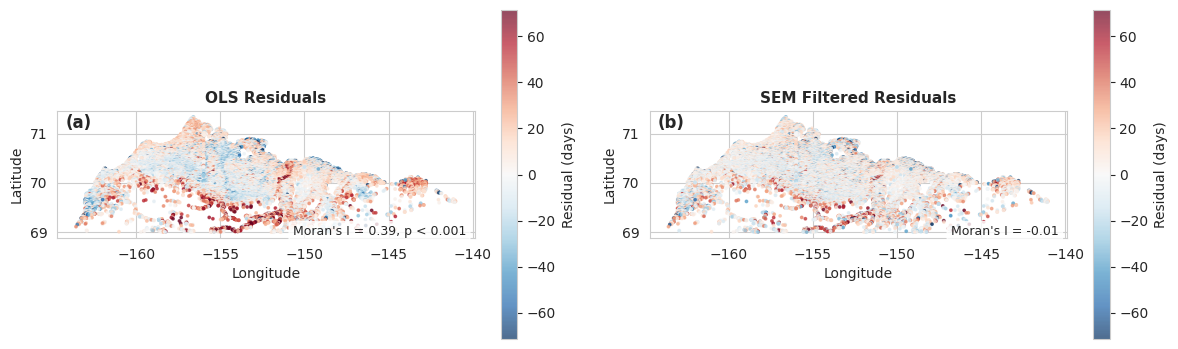

Saved: figures/supplementary/figS13_residual_maps.png
  OLS Moran's I = 0.39, SEM Moran's I = -0.01


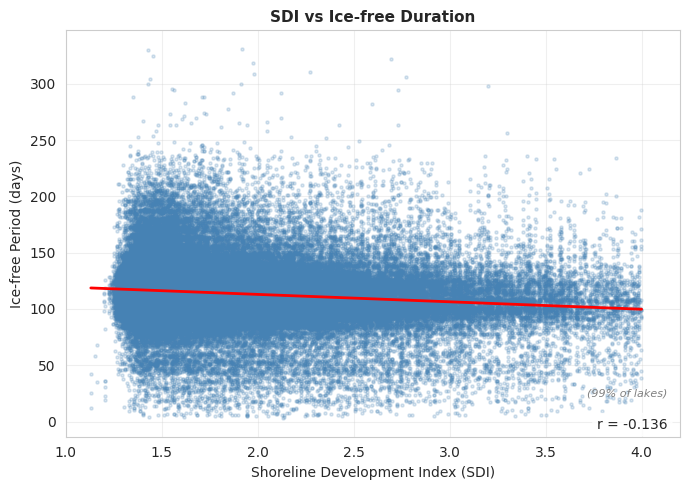

Saved: figures/supplementary/figS14_sdi_scatter.png


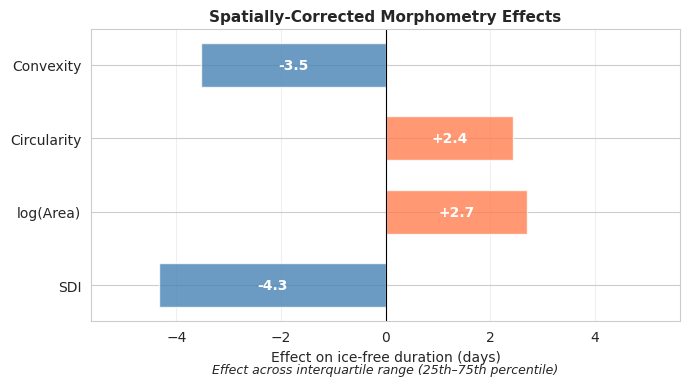

Saved: figures/manuscript/fig05_spatial_morphometry.png

Spatially-corrected effects across IQR:
  SDI: -4.3 days
  log(Area): +2.7 days
  Circularity: +2.4 days
  Convexity: -3.5 days


In [38]:
# ============================================================
# Spatial Correction Analysis - shared computations
# ============================================================

from esda.moran import Moran
import scipy.sparse as sp

y_var = 'ice_free_days'
aspect_ratio = np.cos(np.radians(70))

# Get OLS residuals
ols = lm_results[y_var]['ols']
ols_resid = ols.u.flatten()

# Get SEM filtered residuals: ε = u - λWu
sem = sem_results[y_var]
u = sem.u.flatten()
lambda_val = sem.betas[-1][0]
W_sparse = w.sparse
Wu = W_sparse @ u
epsilon = u - lambda_val * Wu

# Compute Moran's I for both
moran_ols = Moran(ols_resid, w)
moran_sem = Moran(epsilon, w)

# Add residuals to lake_spatial for plotting
lake_spatial_plot = lake_spatial.copy()
lake_spatial_plot['ols_resid'] = ols_resid
lake_spatial_plot['sem_resid'] = epsilon

resid_lim = np.percentile(np.abs(ols_resid), 99)

# ============================================================
# SUPPLEMENTARY FIGURE S13: OLS vs SEM Residual Maps
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel (a): OLS Residuals Map
ax = axes[0]
scatter = ax.scatter(lake_spatial_plot['centroid_lon'], lake_spatial_plot['centroid_lat'],
                     c=lake_spatial_plot['ols_resid'], cmap='RdBu_r', s=3, alpha=0.7,
                     vmin=-resid_lim, vmax=resid_lim)
plt.colorbar(scatter, ax=ax, label='Residual (days)', shrink=0.7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('OLS Residuals', fontweight='bold')
ax.set_aspect(1/aspect_ratio)
ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontweight='bold', fontsize=12, va='top')
ax.text(0.98, 0.02, f"Moran's I = {moran_ols.I:.2f}, p < 0.001",
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel (b): SEM Filtered Residuals Map
ax = axes[1]
scatter = ax.scatter(lake_spatial_plot['centroid_lon'], lake_spatial_plot['centroid_lat'],
                     c=lake_spatial_plot['sem_resid'], cmap='RdBu_r', s=3, alpha=0.7,
                     vmin=-resid_lim, vmax=resid_lim)
plt.colorbar(scatter, ax=ax, label='Residual (days)', shrink=0.7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SEM Filtered Residuals', fontweight='bold')
ax.set_aspect(1/aspect_ratio)
ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontweight='bold', fontsize=12, va='top')
ax.text(0.98, 0.02, f"Moran's I = {moran_sem.I:.2f}",
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('./figures/supplementary/figS13_residual_maps.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS13_residual_maps.png")
print(f"  OLS Moran's I = {moran_ols.I:.2f}, SEM Moran's I = {moran_sem.I:.2f}")

# ============================================================
# SUPPLEMENTARY FIGURE S14: SDI vs Ice-free Duration
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

complete_filtered = complete[complete['sdi'] <= 4].copy()
ax.scatter(complete_filtered['sdi'], complete_filtered['ice_free_days'],
           alpha=0.2, s=5, c='steelblue')

mask = complete_filtered['sdi'].notna() & complete_filtered['ice_free_days'].notna()
r_sdi, p_sdi = stats.pearsonr(complete_filtered.loc[mask, 'sdi'],
                               complete_filtered.loc[mask, 'ice_free_days'])
slope, intercept = np.polyfit(complete_filtered.loc[mask, 'sdi'],
                              complete_filtered.loc[mask, 'ice_free_days'], 1)
x_line = np.linspace(complete_filtered['sdi'].min(), 4, 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2)

ax.set_xlabel('Shoreline Development Index (SDI)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('SDI vs Ice-free Duration', fontweight='bold')
ax.set_xlim(1, 4.2)
ax.grid(True, alpha=0.3)
ax.text(0.98, 0.02, f'r = {r_sdi:.3f}', transform=ax.transAxes, ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(0.98, 0.10, '(99% of lakes)', transform=ax.transAxes, ha='right', fontsize=8,
        style='italic', color='gray')

plt.tight_layout()
plt.savefig('./figures/supplementary/figS14_sdi_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS14_sdi_scatter.png")

# ============================================================
# MANUSCRIPT FIGURE 6: Spatially-Corrected Morphometry Effects
# ============================================================

fig, ax = plt.subplots(figsize=(7, 4))

morph_vars = ['sdi', 'log_area', 'circularity', 'convexity']
morph_labels = ['SDI', 'log(Area)', 'Circularity', 'Convexity']

effects = []
for var in morph_vars:
    idx = x_vars.index(var)
    sem_coef = sem.betas[idx+1][0]
    p25 = lake_spatial[var].quantile(0.25)
    p75 = lake_spatial[var].quantile(0.75)
    iqr = p75 - p25
    effect = sem_coef * iqr
    effects.append(effect)

y_pos = np.arange(len(morph_vars))
colors = ['steelblue' if e < 0 else 'coral' for e in effects]
bars = ax.barh(y_pos, effects, color=colors, alpha=0.8, height=0.6)

for i, (bar, effect) in enumerate(zip(bars, effects)):
    if abs(effect) > 1.5:
        x_pos = effect * 0.5
        ha = 'center'
        color = 'white'
    else:
        x_pos = effect + (0.5 if effect >= 0 else -0.5)
        ha = 'left' if effect >= 0 else 'right'
        color = 'black'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{effect:+.1f}',
            va='center', ha=ha, fontsize=10, fontweight='bold', color=color)

ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(morph_labels)
ax.set_xlabel('Effect on ice-free duration (days)')
ax.set_title('Spatially-Corrected Morphometry Effects', fontweight='bold')
ax.text(0.5, -0.18, 'Effect across interquartile range (25th\u201375th percentile)',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic')
ax.grid(True, alpha=0.3, axis='x')

x_max = max(abs(e) for e in effects) * 1.3
ax.set_xlim(-x_max, x_max)

plt.tight_layout()
plt.savefig('./figures/manuscript/fig05_spatial_morphometry.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: figures/manuscript/fig05_spatial_morphometry.png")
print(f"\nSpatially-corrected effects across IQR:")
for label, effect in zip(morph_labels, effects):
    print(f"  {label}: {effect:+.1f} days")


## Part 9: Summary Statistics Report

In [39]:
print("="*70)
print("ALASKA LAKE ICE PHENOLOGY - CORRELATION ANALYSIS SUMMARY")
print("="*70)

print("\n" + "-"*70)
print("1. LATITUDE EFFECTS")
print("-"*70)

# Calculate correlations
mask = complete['centroid_lat'].notna() & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    r_off, p_off = stats.pearsonr(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_off_doy'])
    r_on, p_on = stats.pearsonr(complete.loc[mask, 'centroid_lat'], complete.loc[mask, 'ice_on_doy'])
    
    print(f"\nCorrelation with latitude:")
    print(f"  Ice-off DOY:      r = {r_off:+.3f} (p = {p_off:.2e})")
    print(f"  Ice-on DOY:       r = {r_on:+.3f} (p = {p_on:.2e})")
    
    # Ice-free days correlation (handle NaN)
    ifd_mask = complete['ice_free_days'].notna() & complete['centroid_lat'].notna()
    if ifd_mask.sum() > 2:
        r_free, p_free = stats.pearsonr(complete.loc[ifd_mask, 'centroid_lat'], complete.loc[ifd_mask, 'ice_free_days'])
        print(f"  Ice-free days:    r = {r_free:+.3f} (p = {p_free:.2e})")
else:
    print("Insufficient data for latitude correlation analysis")

print("\n" + "-"*70)
print("2. LAKE SIZE EFFECTS")
print("-"*70)

# Spearman for log-like relationships
mask = (complete['area_km2'] > 0) & complete['ice_off_doy'].notna()
if mask.sum() > 2:
    r_off, p_off = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_off_doy'])
    r_on, p_on = stats.spearmanr(complete.loc[mask, 'area_km2'], complete.loc[mask, 'ice_on_doy'])

    print(f"\nSpearman correlation with lake area:")
    print(f"  Ice-off DOY:      r = {r_off:+.3f} (p = {p_off:.2e})")
    print(f"  Ice-on DOY:       r = {r_on:+.3f} (p = {p_on:.2e})")
    
    ifd_mask = (complete['area_km2'] > 0) & complete['ice_free_days'].notna()
    if ifd_mask.sum() > 2:
        r_free, p_free = stats.spearmanr(complete.loc[ifd_mask, 'area_km2'], complete.loc[ifd_mask, 'ice_free_days'])
        print(f"  Ice-free days:    r = {r_free:+.3f} (p = {p_free:.2e})")
else:
    print("Insufficient data for size correlation analysis")

print("\n" + "-"*70)
print("3. SHAPE METRICS EFFECTS")
print("-"*70)

for var, label in [('circularity', 'Circularity'), ('sdi', 'SDI'), ('convexity', 'Convexity')]:
    if var in complete.columns:
        mask = complete[var].notna() & complete['ice_free_days'].notna()
        if mask.sum() > 2:
            r, p = stats.pearsonr(complete.loc[mask, var], complete.loc[mask, 'ice_free_days'])
            print(f"  {label:12s} vs ice-free days: r = {r:+.3f} (p = {p:.2e})")
        else:
            print(f"  {label:12s}: insufficient data")
    else:
        print(f"  {label:12s}: not available in dataset")

print("\n" + "-"*70)
print("4. DATA SUMMARY")
print("-"*70)

years = complete['year'].unique()
if len(years) > 1:
    yearly_means = complete.groupby('year')['ice_free_days'].mean()
    print(f"\nMean ice-free days by year:")
    for year, val in yearly_means.items():
        print(f"  {year}: {val:.1f} days")
    print(f"\nRange: {yearly_means.max() - yearly_means.min():.1f} days")
    print(f"Std:   {yearly_means.std():.1f} days")
else:
    print(f"\nSingle year dataset: {years[0]}")
    print(f"Total lakes analyzed: {len(complete)}")
    print(f"Lakes with ice-free days: {complete['ice_free_days'].notna().sum()}")

print("\n" + "="*70)

ALASKA LAKE ICE PHENOLOGY - CORRELATION ANALYSIS SUMMARY

----------------------------------------------------------------------
1. LATITUDE EFFECTS
----------------------------------------------------------------------

Correlation with latitude:
  Ice-off DOY:      r = +0.522 (p = 0.00e+00)
  Ice-on DOY:       r = -0.364 (p = 0.00e+00)
  Ice-free days:    r = -0.501 (p = 0.00e+00)

----------------------------------------------------------------------
2. LAKE SIZE EFFECTS
----------------------------------------------------------------------

Spearman correlation with lake area:
  Ice-off DOY:      r = +0.073 (p = 8.99e-177)
  Ice-on DOY:       r = +0.101 (p = 0.00e+00)
  Ice-free days:    r = +0.023 (p = 9.22e-19)

----------------------------------------------------------------------
3. SHAPE METRICS EFFECTS
----------------------------------------------------------------------
  Circularity  vs ice-free days: r = +0.131 (p = 0.00e+00)
  SDI          vs ice-free days: r = -0.143 (p

In [40]:
# Check correlations between morphometry and temperature/location
# These would indicate potential confounding in the regression analysis
# NOTE: This cell requires ERA5 data which is loaded later in ADDT analysis
# Skip if mean_spring_temp is not yet available

morph_vars = ['log_area', 'sdi', 'circularity', 'convexity']
location_vars = ['centroid_lat', 'centroid_lon']

# Check if mean_spring_temp is available (it's computed in ADDT analysis cell)
if 'mean_spring_temp' not in dir():
    print("="*70)
    print("CONFOUNDING CHECK: Skipped")
    print("="*70)
    print("\nNOTE: This analysis requires ERA5 temperature data.")
    print("Run the ADDT analysis cell first, or see confounding results below in that section.")
else:
    # Compute mean spring temperature per lake (across years)
    lake_temp = complete.merge(mean_spring_temp, on=['lake_id', 'year'], how='inner')
    lake_temp_mean = lake_temp.groupby('lake_id').agg({
        'mean_spring_temp': 'mean',
        'centroid_lat': 'first',
        'centroid_lon': 'first',
        'log_area': 'first',
        'sdi': 'first',
        'circularity': 'first',
        'convexity': 'first'
    }).reset_index()
    
    print("="*70)
    print("CONFOUNDING CHECK: Morphometry vs Temperature/Location")
    print("="*70)
    print("\nCorrelations between morphometry and potential confounders:")
    print("-"*70)
    
    # Build correlation table
    confound_corrs = []
    for morph in morph_vars:
        row = {'Morphometry': morph}
        
        # Correlation with temperature
        mask = lake_temp_mean[morph].notna() & lake_temp_mean['mean_spring_temp'].notna()
        r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'mean_spring_temp'])
        row['vs Temperature'] = f"r={r:+.3f}"
        
        # Correlation with latitude
        mask = lake_temp_mean[morph].notna() & lake_temp_mean['centroid_lat'].notna()
        r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'centroid_lat'])
        row['vs Latitude'] = f"r={r:+.3f}"
        
        # Correlation with longitude
        mask = lake_temp_mean[morph].notna() & lake_temp_mean['centroid_lon'].notna()
        r, p = stats.pearsonr(lake_temp_mean.loc[mask, morph], lake_temp_mean.loc[mask, 'centroid_lon'])
        row['vs Longitude'] = f"r={r:+.3f}"
        
        confound_corrs.append(row)
    
    confound_df = pd.DataFrame(confound_corrs)
    display(confound_df.set_index('Morphometry'))
    
    # Check temperature-latitude correlation (known confounder)
    mask = lake_temp_mean['mean_spring_temp'].notna() & lake_temp_mean['centroid_lat'].notna()
    r_temp_lat, _ = stats.pearsonr(lake_temp_mean.loc[mask, 'centroid_lat'], 
                                    lake_temp_mean.loc[mask, 'mean_spring_temp'])
    print(f"\nTemperature-Latitude correlation: r = {r_temp_lat:.3f}")
    
    print("\n" + "-"*70)
    print("INTERPRETATION:")
    print("-"*70)
    print("""
• |r| < 0.1: Negligible confounding
• 0.1 ≤ |r| < 0.3: Weak confounding (interpret with caution)
• |r| ≥ 0.3: Moderate-strong confounding (temperature control essential)

If morphometry is uncorrelated with temperature/location, regression 
coefficients for morphometry are unlikely to be biased by spatial confounding.
""")

CONFOUNDING CHECK: Morphometry vs Temperature/Location

Correlations between morphometry and potential confounders:
----------------------------------------------------------------------


,vs Temperature,vs Latitude,vs Longitude
Morphometry,,,
log_area,r=-0.019,r=+0.060,r=-0.044
sdi,r=-0.096,r=+0.047,r=+0.056
circularity,r=+0.106,r=-0.045,r=-0.072
convexity,r=+0.034,r=+0.032,r=-0.080



Temperature-Latitude correlation: r = -0.807

----------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------

• |r| < 0.1: Negligible confounding
• 0.1 ≤ |r| < 0.3: Weak confounding (interpret with caution)
• |r| ≥ 0.3: Moderate-strong confounding (temperature control essential)

If morphometry is uncorrelated with temperature/location, regression 
coefficients for morphometry are unlikely to be biased by spatial confounding.



## Summary

This notebook analyzed correlations between lake ice phenology and various lake characteristics:

**Key Findings:**

1. **Latitude Effects**: Higher latitude lakes tend to have:
   - Later ice-off dates (longer winter)
   - Earlier ice-on dates (earlier freeze-up)
   - Shorter ice-free periods

2. **Lake Size Effects**: Larger lakes tend to have:
   - Later ice-off (thermal inertia delays spring melt)
   - Later ice-on (thermal inertia delays fall freeze)
   - Overall longer ice-free periods

3. **Shape Metrics**: Lake shape (circularity, SDI, convexity) shows weak correlations with phenology in simple analyses

4. **Inter-annual Variability**: Year-to-year variation in ice-free duration is substantial, reflecting climate variability

5. **Spatial Patterns**: Clear latitudinal gradients visible in all phenology metrics

6. **Temperature-Controlled Regression**: 
   - Temperature explains ~16% of ice-off/ice-free variance
   - Morphometry adds ~1.5-2% additional explanatory power
   - High residual Moran's I (~0.44) indicates spatial autocorrelation

7. **Spatial Regression**: 
   - Spatial Error and Spatial Lag models address residual spatial autocorrelation
   - Tests whether morphometry effects (especially SDI) are robust to spatial confounding

**Output Files:**
- `figures/latitude_phenology_correlations.png`
- `figures/size_phenology_correlations.png`
- `figures/size_class_boxplots.png`
- `figures/correlation_matrix.png`
- `figures/shape_phenology_correlations.png`
- `figures/interannual_variability.png`
- `figures/interannual_variability_factors.png`
- `figures/spatial_phenology_maps.png`
- `figures/longitude_phenology_correlations.png`
- `figures/phenology_summary_statistics.csv`